# IMPORTACIÓN DE LIBRERÍAS

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# CARGA DEL DATASET

In [50]:
df = pd.read_csv("Bias_Crime.csv")

print(df.head())

              X             Y       CCN                            ADDRESS  \
0 -8.573291e+06  4.708950e+06  13005668              3rd St NW and Q St NW   
1 -8.574028e+06  4.717080e+06  13016960      600 block of Tewkesbury Pl NW   
2 -8.574159e+06  4.707780e+06  13017988       800 block of Mt Vernon Pl NW   
3 -8.572502e+06  4.698018e+06  13024055  3800 block of South Capitol St SE   
4 -8.575301e+06  4.709790e+06  13027781              1400 block of U St NW   

          DATE_OF_OFFENSE TIME_OF_OFFENSE   DATE_OFFENSE_RECORDED  \
0  2013/01/13 05:00:00+00       1808-1809  2013/01/13 05:00:00+00   
1  2013/02/05 05:00:00+00            2200  2013/02/07 05:00:00+00   
2  2013/02/09 05:00:00+00       1400-1405  2013/02/09 05:00:00+00   
3  2013/02/22 05:00:00+00       1440-1448  2013/02/22 05:00:00+00   
4  2013/03/03 05:00:00+00       0159-0200  2013/03/03 05:00:00+00   

   REPORT_YEAR  MONTH POLICE_DISTRICT  ...     MAR_XCOORD     MAR_YCOORD  \
0         2013      1              5D  .

# EXPLORACIÓN INICIAL

In [51]:
print(df.shape)

(1656, 25)


## Ver columnas

In [52]:
print(df.columns)

Index(['X', 'Y', 'CCN', 'ADDRESS', 'DATE_OF_OFFENSE', 'TIME_OF_OFFENSE',
       'DATE_OFFENSE_RECORDED', 'REPORT_YEAR', 'MONTH', 'POLICE_DISTRICT',
       'WARD', 'TYPE_OF_HATE_BIAS', 'TARGETED_GROUP', 'TOP_OFFENSE_TYPE',
       'MAR_ID', 'MAR_XCOORD', 'MAR_YCOORD', 'MAR_LATITUDE', 'MAR_LONGITUDE',
       'CREATED_USER', 'CREATED_DATE', 'LAST_EDITED_USER', 'LAST_EDITED_DATE',
       'OBJECTID', 'SE_ANNO_CAD_DATA'],
      dtype='object')


## Ver tipo de datos

In [53]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1656 entries, 0 to 1655
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X                      1644 non-null   float64
 1   Y                      1644 non-null   float64
 2   CCN                    1656 non-null   int64  
 3   ADDRESS                1656 non-null   object 
 4   DATE_OF_OFFENSE        1656 non-null   object 
 5   TIME_OF_OFFENSE        1656 non-null   object 
 6   DATE_OFFENSE_RECORDED  1656 non-null   object 
 7   REPORT_YEAR            1656 non-null   int64  
 8   MONTH                  1656 non-null   int64  
 9   POLICE_DISTRICT        1656 non-null   object 
 10  WARD                   1644 non-null   object 
 11  TYPE_OF_HATE_BIAS      1656 non-null   object 
 12  TARGETED_GROUP         841 non-null    object 
 13  TOP_OFFENSE_TYPE       1651 non-null   object 
 14  MAR_ID                 1644 non-null   float64
 15  MAR_

## Ver valores nulos

In [54]:
print(df.isnull().sum())

X                          12
Y                          12
CCN                         0
ADDRESS                     0
DATE_OF_OFFENSE             0
TIME_OF_OFFENSE             0
DATE_OFFENSE_RECORDED       0
REPORT_YEAR                 0
MONTH                       0
POLICE_DISTRICT             0
WARD                       12
TYPE_OF_HATE_BIAS           0
TARGETED_GROUP            815
TOP_OFFENSE_TYPE            5
MAR_ID                     12
MAR_XCOORD                 12
MAR_YCOORD                 12
MAR_LATITUDE               16
MAR_LONGITUDE              16
CREATED_USER             1523
CREATED_DATE             1523
LAST_EDITED_USER            0
LAST_EDITED_DATE            0
OBJECTID                    0
SE_ANNO_CAD_DATA         1656
dtype: int64


## qué años hay en el dataset

In [55]:
print(sorted(df["REPORT_YEAR"].unique()))

[np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Ver delitos por año

In [56]:
years = df["REPORT_YEAR"].value_counts().sort_index()

print("Número de delitos por año:\n")
print(years)

Número de delitos por año:

REPORT_YEAR
2012     80
2013     68
2014     70
2015     66
2016    106
2017    177
2018    205
2019    203
2020    132
2021    149
2022    129
2023    150
2024    121
Name: count, dtype: int64


In [93]:
years = df["REPORT_YEAR"].value_counts().sort_index().describe()
print(years)

count     13.000000
mean     126.153846
std       48.610435
min       64.000000
25%       79.000000
50%      129.000000
75%      150.000000
max      205.000000
Name: count, dtype: float64


## Ver cómo están los datos sobre las horas en que se comenten los delitos

In [57]:
print(df["TIME_OF_OFFENSE"].head(20))

0     1808-1809
1          2200
2     1400-1405
3     1440-1448
4     0159-0200
5          2034
6          1400
7     2249-2250
8          1737
9     0210-0215
10         0124
11         1904
12         1044
13         5300
14         1800
15    1800-1900
16    0115-0118
17         0215
18         1800
19         1957
Name: TIME_OF_OFFENSE, dtype: object


# LIMPIEZA DE DATOS

## Eliminar columnas innecesarias

In [58]:
columns_to_drop = [
    "X",
    "Y",
    "CCN",
    "MAR_ID",
    "MAR_XCOORD",
    "MAR_YCOORD",
    "CREATED_USER",
    "CREATED_DATE",
    "LAST_EDITED_USER",
    "LAST_EDITED_DATE",
    "OBJECTID",
    "SE_ANNO_CAD_DATA"
]

df = df.drop(columns=columns_to_drop)

## Convertir fechas

In [59]:
# Convertir a datetime

df["DATE_OF_OFFENSE"] = pd.to_datetime(df["DATE_OF_OFFENSE"])

## Crear nuevas variables temporales

In [60]:
# Año

df["YEAR"] = df["DATE_OF_OFFENSE"].dt.year

# Día semana

df["DAY_OF_WEEK"] = df["DATE_OF_OFFENSE"].dt.day_name()

# Mes

df["MONTH_NAME"] = df["DATE_OF_OFFENSE"].dt.month_name()

## Revisar duplicados

In [61]:
print(df.duplicated().sum())

0


## Agrupaciones por categorías

In [62]:
# categorías que incluye el dataset

print(df["TARGETED_GROUP"].unique())

[nan 'Jewish' 'Asian' 'Latino/Hispanic' 'White' 'Black' 'Multiple'
 'Unspecified' 'Muslim' 'Indian' 'Arab/Middle Eastern' 'Black/African'
 'Christian' 'Other/Unknown Religion' 'Hindu' 'Middle Eastern' 'Female'
 'Jamaican' 'Arab/Middle Eastern or Jewish' 'Non-European' 'African'
 'Mexican' 'Ukrainian' 'Hispanic; Homelessness' 'Ethiopian' 'Catholic'
 'Chinese' 'Pakistani' 'Hispanic' 'Japanese' 'Turkish' 'Iranian'
 'Lebanese' 'White; Jewish' 'Russian' 'ADW' 'Homicide' 'Black; Jewish'
 'Israeli' 'Palestinian' 'Unknown' 'Taiwanese' 'Oromo'
 'Muslim; Middle Eastern' 'Indian; Middle Eastern' 'Jewish; Non-European'
 'Colombian' 'Non-Palestinian' 'Guatemalan' 'Jewish; Hispanic']


## Agrupación de las categorías en 13 grupos

In [63]:
def agrupar_grupo(grupo):

    grupo = str(grupo).lower()

    # Black / African
    
    if (
        "black" in grupo or
        "african" in grupo or
        "ethiopian" in grupo
    ):
        return "Black/African"

    # Jewish
    

    elif "jewish" in grupo:
        return "Jewish"

    # White

    elif (
        "white" in grupo or
        "european" in grupo or
        "russian" in grupo or
        "ukrainian" in grupo
    ):
        return "White"

    # Hispanic / Latino

    elif (
        "hispanic" in grupo or
        "latino" in grupo or
        "mexican" in grupo or
        "colombian" in grupo or
        "guatemalan" in grupo
    ):
        return "Hispanic/Latino"

    # Asian

    elif (
        "asian" in grupo or
        "chinese" in grupo or
        "japanese" in grupo or
        "indian" in grupo or
        "pakistani" in grupo or
        "taiwanese" in grupo
    ):
        return "Asian"

    # Muslim

    elif "muslim" in grupo:
        return "Muslim"

    # Eastern

    elif (
        "arab" in grupo or
        "eastern" in grupo or
        "palestinian" in grupo or
        "iranian" in grupo or
        "lebanese" in grupo
    ):
        return "Eastern"

    # Christian

    elif (
        "christian" in grupo or
        "catholic" in grupo or
        "hindu" in grupo
    ):
        return "Religion"

    # Gender

    elif "female" in grupo:
        return "Gender"

    # LGBTQ+

    elif (
        "gay" in grupo or
        "lgbt" in grupo or
        "trans" in grupo
    ):
        return "LGBTQ+"

    # Unknown

    elif (
        "unknown" in grupo or
        "unspecified" in grupo
    ):
        return "Unknown"

    # Multiple

    elif ';' in grupo or "multiple" in grupo:
        return 'Multiple'

    # Other

    else:
        return "Other"

In [101]:
print(df["TARGETED_GROUP"])

0            NaN
1         Jewish
2            NaN
3            NaN
4            NaN
          ...   
1651      Jewish
1652         NaN
1653    Hispanic
1654         NaN
1655       White
Name: TARGETED_GROUP, Length: 1640, dtype: object


## Dataset limpio

In [64]:
# Guardar dataset limpio

df.to_csv("Bias_Crime_Limpio.csv", index=False)

# EDA — Exploratory Data Analysis

## Evolución de delitos por año

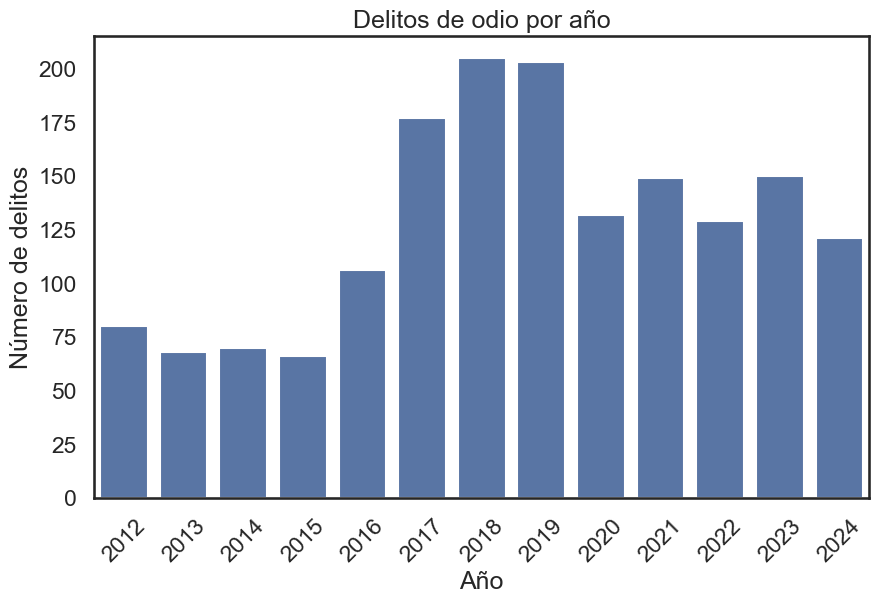

In [65]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="REPORT_YEAR")

plt.title("Delitos de odio por año")
plt.xlabel("Año")
plt.ylabel("Número de delitos")

plt.xticks(rotation=45)

plt.show()

In [120]:
print(df["REPORT_YEAR"].value_counts())

REPORT_YEAR
2018    205
2019    200
2017    176
2023    150
2021    146
2020    132
2022    129
2024    117
2016    104
2012     79
2014     70
2013     68
2015     64
Name: count, dtype: int64


In [122]:
print(df["REPORT_YEAR"].value_counts().describe())

count     13.000000
mean     126.153846
std       48.610435
min       64.000000
25%       79.000000
50%      129.000000
75%      150.000000
max      205.000000
Name: count, dtype: float64


## Delitos por mes

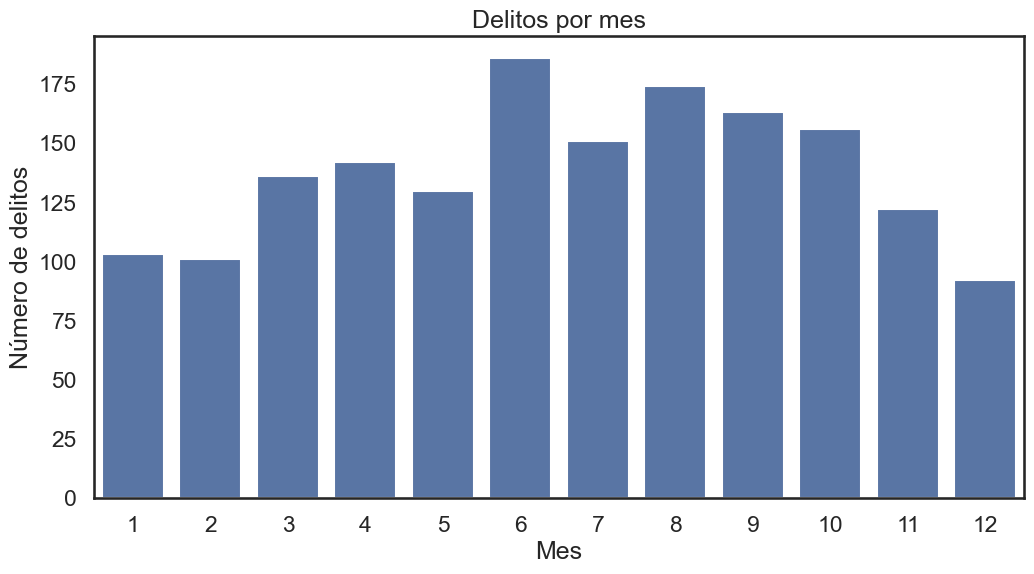

In [66]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="MONTH")

plt.title("Delitos por mes")
plt.xlabel("Mes")
plt.ylabel("Número de delitos")

plt.show()

In [102]:
print(df["MONTH"])

0       1
1       2
2       2
3       2
4       3
       ..
1651    5
1652    5
1653    5
1654    5
1655    5
Name: MONTH, Length: 1640, dtype: int32


## Cada cuánto se comete un delito de odio en Washington

In [67]:
# CONVERTIR COLUMNA A FORMATO FECHA

df["DATE_OF_OFFENSE"] = pd.to_datetime(
    df["DATE_OF_OFFENSE"]
)

# ORDENAR INCIDENTES POR FECHA

df = df.sort_values("DATE_OF_OFFENSE")

# CALCULAR TIEMPO ENTRE DELITOS

df["TIME_BETWEEN_CRIMES"] = (
    df["DATE_OF_OFFENSE"]
    .diff()
)

# CALCULAR FRECUENCIA MEDIA

average_frequency = (
    df["TIME_BETWEEN_CRIMES"]
    .mean()
)

# CONVERTIR A DÍAS

days = (
    average_frequency.total_seconds()
    / 86400
)

# CONVERTIR A HORAS

hours = (
    average_frequency.total_seconds()
    / 3600
)

# MOSTRAR RESULTADOS

print(
    f"A hate crime occurs every {days:.2f} days on average."
)

print(
    f"A hate crime occurs every {hours:.2f} hours on average."
)

A hate crime occurs every 2.81 days on average.
A hate crime occurs every 67.34 hours on average.


## Histograma de frecuencias

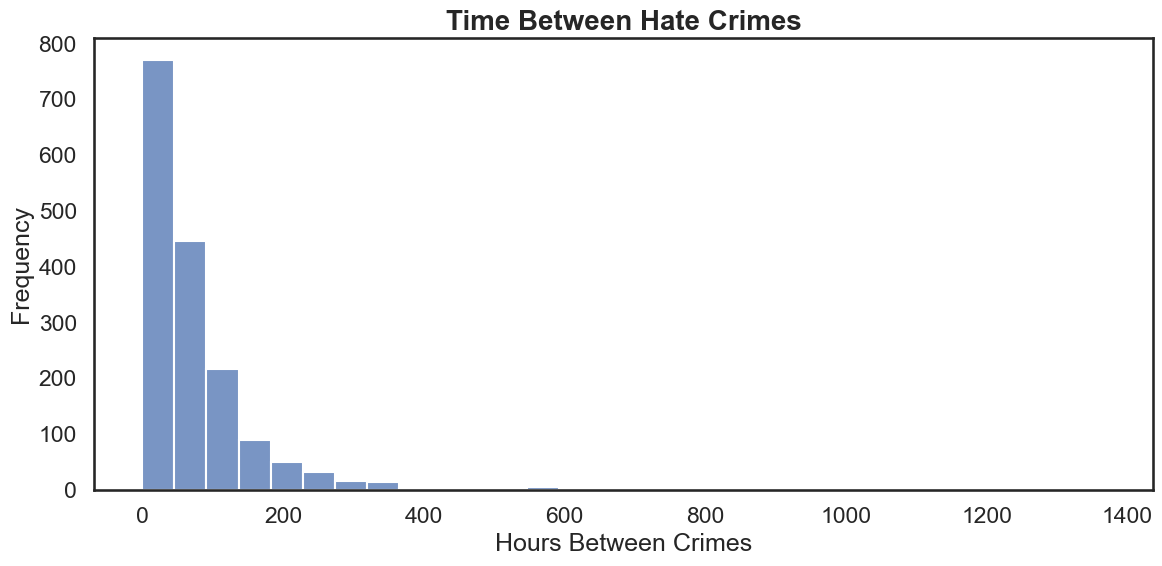

In [68]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["TIME_BETWEEN_CRIMES"]
    .dt.total_seconds() / 3600,
    bins=30
)

plt.title(
    "Time Between Hate Crimes",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Hours Between Crimes")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Análisis del tipo de delito según presidencia de los Estados Unidos

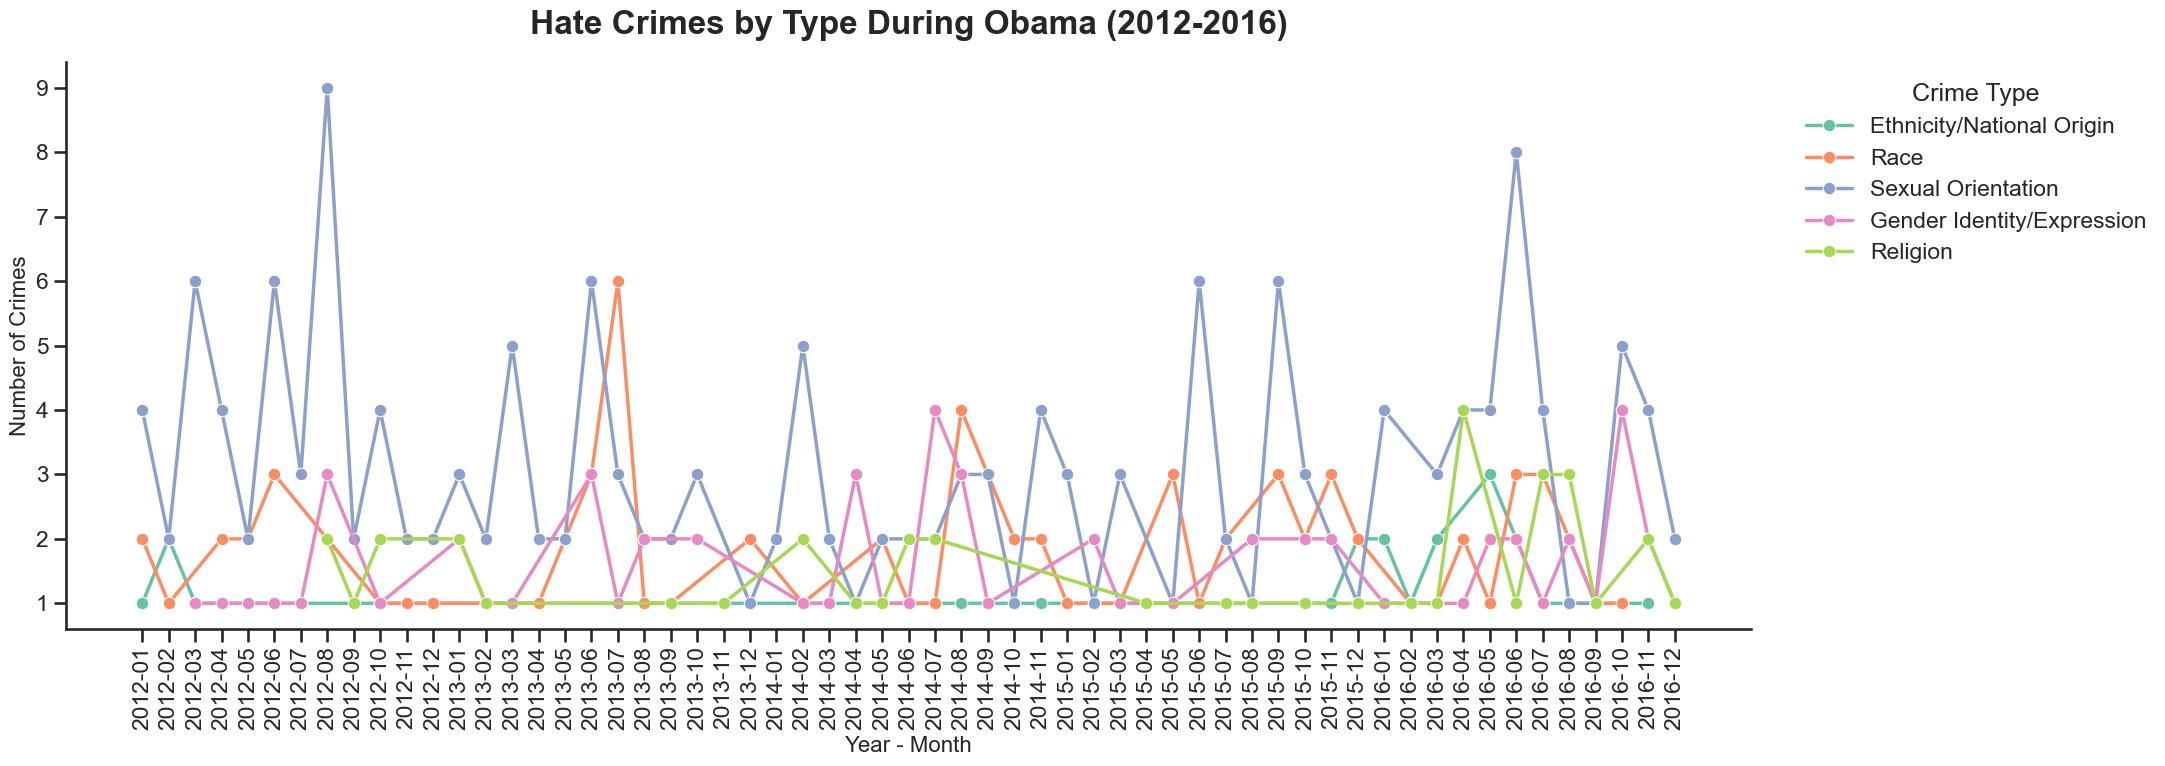

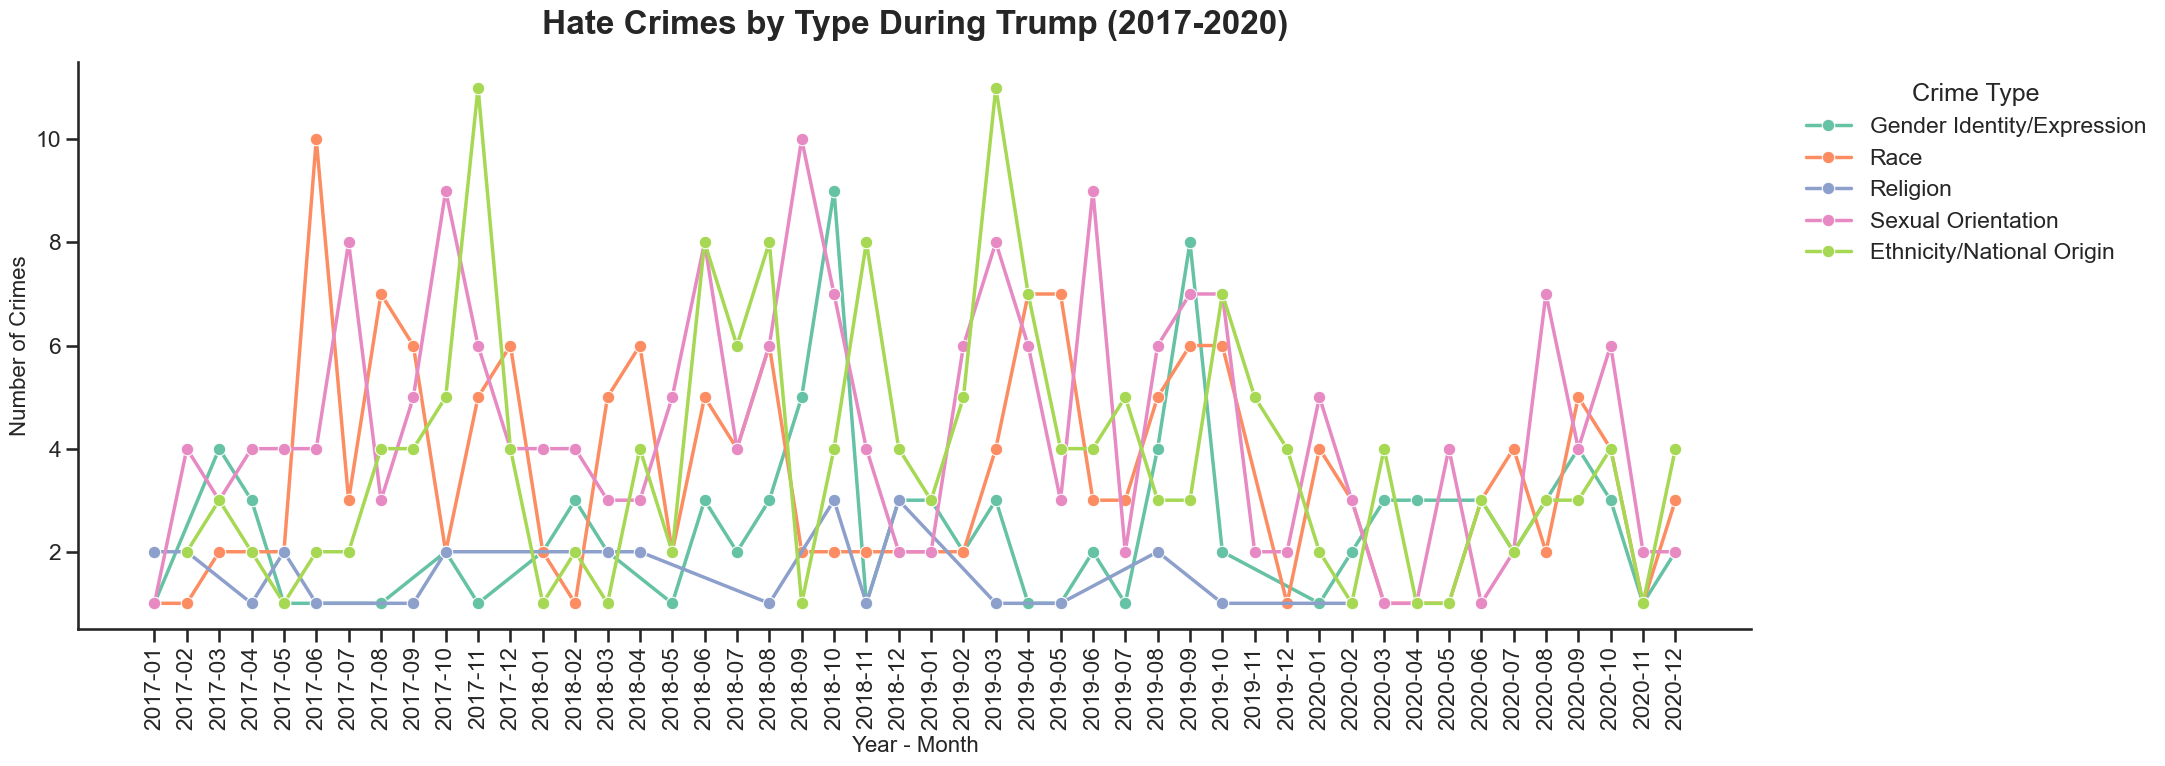

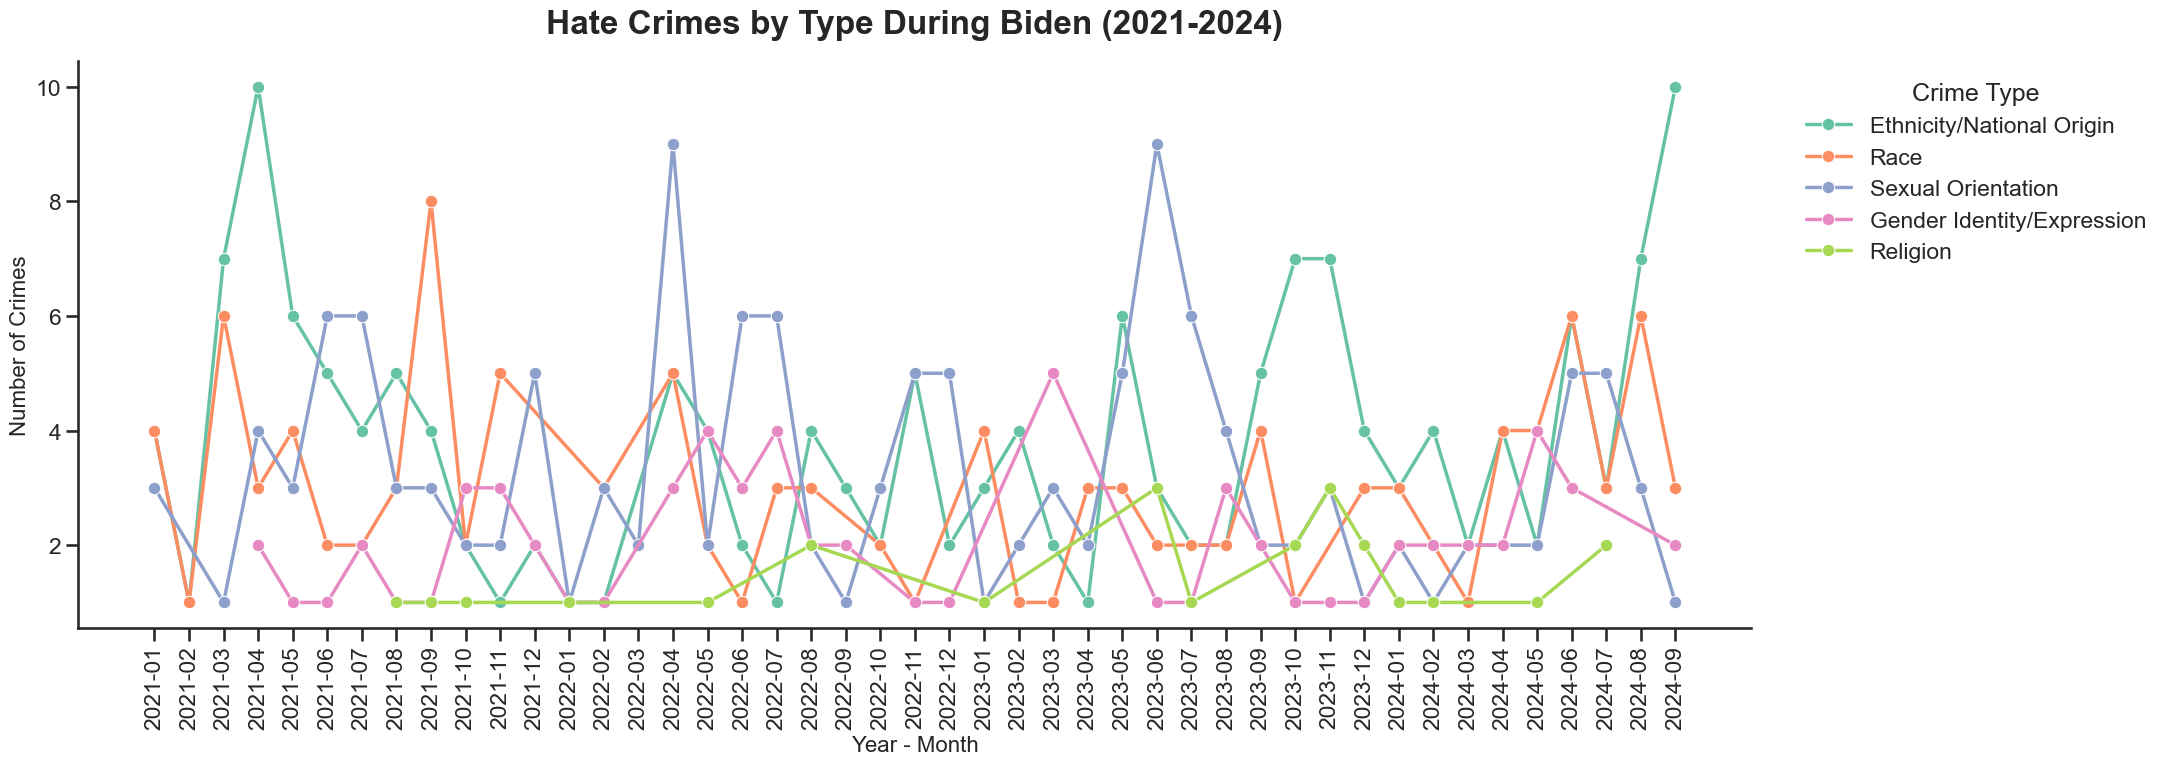

In [69]:

# ESTILO GENERAL

sns.set_theme(
    style="ticks",
    palette="Set2",
    context="talk"
)

# COLUMNA DE TIPO DE DELITO

crime_type_col = "TYPE_OF_HATE_BIAS"

# CREAR COLUMNA AÑO-MES

df["YEAR_MONTH"] = (
    df["REPORT_YEAR"].astype(str)
    + "-"
    + df["MONTH"].astype(str).str.zfill(2)
)

# CONTAR DELITOS

crime_counts = (
    df.groupby(
        ["REPORT_YEAR", "YEAR_MONTH", crime_type_col]
    )
    .size()
    .reset_index(name="COUNT")
)

# TOP 5 TIPOS DE DELITO

top_crimes = (
    crime_counts.groupby(crime_type_col)["COUNT"]
    .sum()
    .nlargest(5)
    .index
)

crime_counts = crime_counts[
    crime_counts[crime_type_col].isin(top_crimes)
]

# PERIODOS PRESIDENCIALES

presidents = {
    "Obama (2012-2016)": (2012, 2016),
    "Trump (2017-2020)": (2017, 2020),
    "Biden (2021-2024)": (2021, 2024)
}

# CREAR GRÁFICOS

for president, (start, end) in presidents.items():

    subset = crime_counts[
        (crime_counts["REPORT_YEAR"] >= start) &
        (crime_counts["REPORT_YEAR"] <= end)
    ].copy()

    subset = subset.sort_values("YEAR_MONTH")

    plt.figure(figsize=(22, 8))

    sns.lineplot(
        data=subset,
        x="YEAR_MONTH",
        y="COUNT",
        hue=crime_type_col,
        linewidth=2.5,
        marker="o"
    )

    # PERSONALIZACIÓN

    plt.title(
        f"Hate Crimes by Type During {president}",
        fontsize=24,
        weight="bold",
        pad=20
    )

    plt.xlabel("Year - Month", fontsize=16)
    plt.ylabel("Number of Crimes", fontsize=16)

    plt.xticks(rotation=90)

    # QUITAR GRID
    plt.grid(False)

    # QUITAR BORDES SUPERIOR Y DERECHO
    sns.despine()

    # LEYENDA
    plt.legend(
        title="Crime Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()

    plt.show()

## Top 10 delitos de odio según presidencia

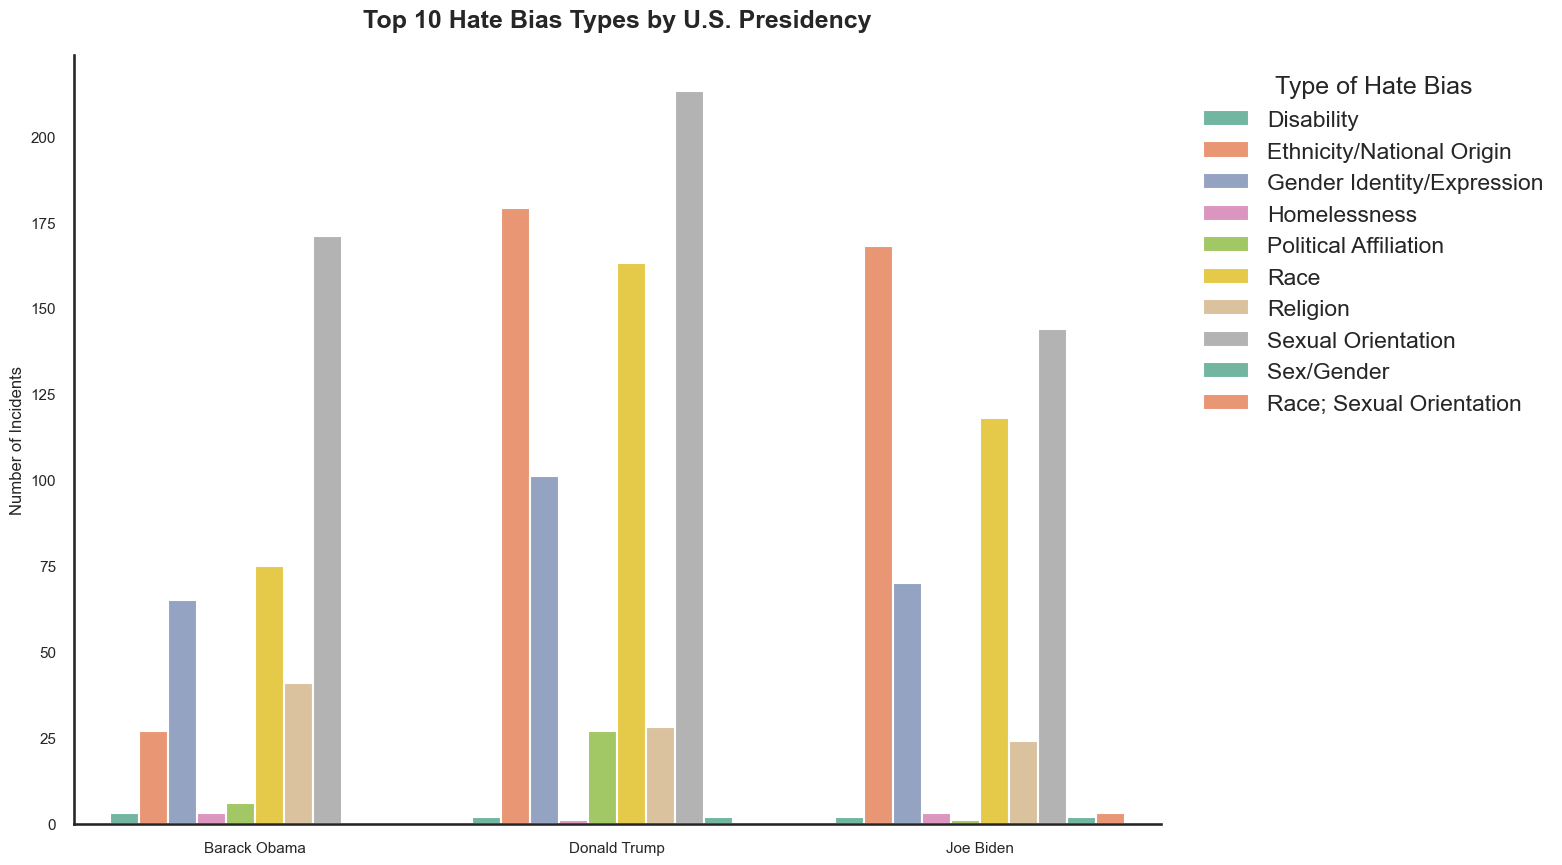

In [70]:

# ESTILO

sns.set_style("white")
plt.figure(figsize=(16, 9))

# DEFINIR PRESIDENCIAS

def assign_president(year):

    if 2012 <= year <= 2016:
        return "Barack Obama"

    elif 2017 <= year <= 2020:
        return "Donald Trump"

    elif 2021 <= year <= 2024:
        return "Joe Biden"

df["PRESIDENT"] = df["YEAR"].apply(assign_president)

# TOP 10 TIPOS DE HATE BIAS

top10_crimes = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .head(10)
    .index
)

# FILTRAR TOP 10

df_top = df[
    df["TYPE_OF_HATE_BIAS"].isin(top10_crimes)
]

# AGRUPAR DATOS

crime_president = (
    df_top
    .groupby(
        ["PRESIDENT", "TYPE_OF_HATE_BIAS"]
    )
    .size()
    .reset_index(name="COUNT")
)

# ORDENAR PRESIDENCIAS

president_order = [
    "Barack Obama",
    "Donald Trump",
    "Joe Biden"
]

crime_president["PRESIDENT"] = pd.Categorical(
    crime_president["PRESIDENT"],
    categories=president_order,
    ordered=True
)

# GRÁFICO

sns.barplot(
    data=crime_president,
    x="PRESIDENT",
    y="COUNT",
    hue="TYPE_OF_HATE_BIAS",
    palette="Set2"
)

# PERSONALIZACIÓN

plt.title(
    "Top 10 Hate Bias Types by U.S. Presidency",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("Number of Incidents", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title="Type of Hate Bias",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

sns.despine()

plt.tight_layout()
plt.show()

In [94]:
print(crime_president)

       PRESIDENT           TYPE_OF_HATE_BIAS  COUNT
0   Barack Obama                  Disability      3
1   Barack Obama   Ethnicity/National Origin     27
2   Barack Obama  Gender Identity/Expression     65
3   Barack Obama                Homelessness      3
4   Barack Obama       Political Affiliation      6
5   Barack Obama                        Race     75
6   Barack Obama                    Religion     41
7   Barack Obama          Sexual Orientation    171
8   Donald Trump                  Disability      2
9   Donald Trump   Ethnicity/National Origin    179
10  Donald Trump  Gender Identity/Expression    101
11  Donald Trump                Homelessness      1
12  Donald Trump       Political Affiliation     27
13  Donald Trump                        Race    163
14  Donald Trump                    Religion     28
15  Donald Trump                  Sex/Gender      2
16  Donald Trump          Sexual Orientation    213
17     Joe Biden                  Disability      2
18     Joe B

In [95]:
crime_president.describe()

,COUNT
count,27.000000
mean,60.814815
std,69.555201
min,1.000000
25%,3.000000
50%,27.000000
75%,109.500000
max,213.000000


## Cuándo se producen estos delitos: día de la semana

In [71]:
print(df["TIME_OF_OFFENSE"].dtype)

object


/var/folders/j0/8nk7kb3139sfbx5j_s7f539m0000gn/T/ipykernel_4008/3376145305.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


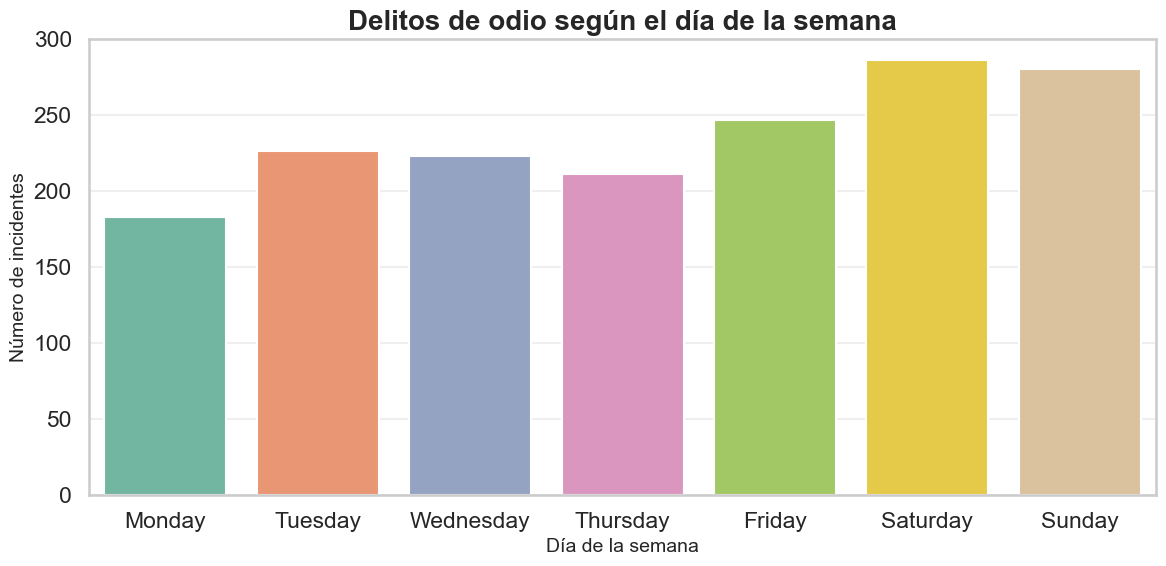

In [72]:


# ESTILO

sns.set_style("whitegrid")

# ORDEN DE LOS DÍAS

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# CONTAR INCIDENTES

day_counts = (
    df["DAY_OF_WEEK"]
    .value_counts()
    .reindex(day_order)
    .reset_index()
)

day_counts.columns = ["DAY_OF_WEEK", "COUNT"]

# GRÁFICO

plt.figure(figsize=(12,6))

sns.barplot(
    data=day_counts,
    x="DAY_OF_WEEK",
    y="COUNT",
    palette="Set2"
)

# PERSONALIZACIÓN

plt.title(
    "Delitos de odio según el día de la semana",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Día de la semana", fontsize=14)
plt.ylabel("Número de incidentes", fontsize=14)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [96]:
print(day_counts)

  DAY_OF_WEEK  COUNT
0      Monday    183
1     Tuesday    226
2   Wednesday    223
3    Thursday    211
4      Friday    247
5    Saturday    286
6      Sunday    280


## Porcentaje de incidencias los fines de semana

In [73]:
# CONVERTIR FECHA

df["DATE_OF_OFFENSE"] = pd.to_datetime(
    df["DATE_OF_OFFENSE"]
)

# CREAR COLUMNA DÍA DE LA SEMANA

df["DAY_OF_WEEK"] = (
    df["DATE_OF_OFFENSE"]
    .dt.day_name()
)

# CALCULAR INCIDENTES EN FIN DE SEMANA

weekend_crimes = df[
    df["DAY_OF_WEEK"].isin(
        ["Saturday", "Sunday"]
    )
].shape[0]

# TOTAL DE INCIDENTES

total_crimes = df.shape[0]

# CALCULAR PORCENTAJE

weekend_percentage = (
    weekend_crimes / total_crimes * 100
)

# REDONDEAR

weekend_percentage = round(
    weekend_percentage,
    2
)

# MOSTRAR RESULTADO

print(
    f"Weekend incidents represent {weekend_percentage}% of total hate crimes."
)

Weekend incidents represent 34.18% of total hate crimes.


## Cuándo se producen estos delitos: hora del día

   TIME_OF_OFFENSE
0        1808-1809
1             2200
2        1400-1405
3        1440-1448
4        0159-0200
5             2034
6             1400
7        2249-2250
8             1737
9        0210-0215
10            0124
11            1904
12            1044
13            5300
14            1800
15       1800-1900
16       0115-0118
17            0215
18            1800
19            1957
   TIME_OF_OFFENSE START_TIME  HOUR
0        1808-1809       1808    18
1             2200       2200    22
2        1400-1405       1400    14
3        1440-1448       1440    14
4        0159-0200       0159     1
5             2034       2034    20
6             1400       1400    14
7        2249-2250       2249    22
8             1737       1737    17
9        0210-0215       0210     2
10            0124       0124     1
11            1904       1904    19
12            1044       1044    10
13            5300       5300    53
14            1800       1800    18
15       1800-1900       

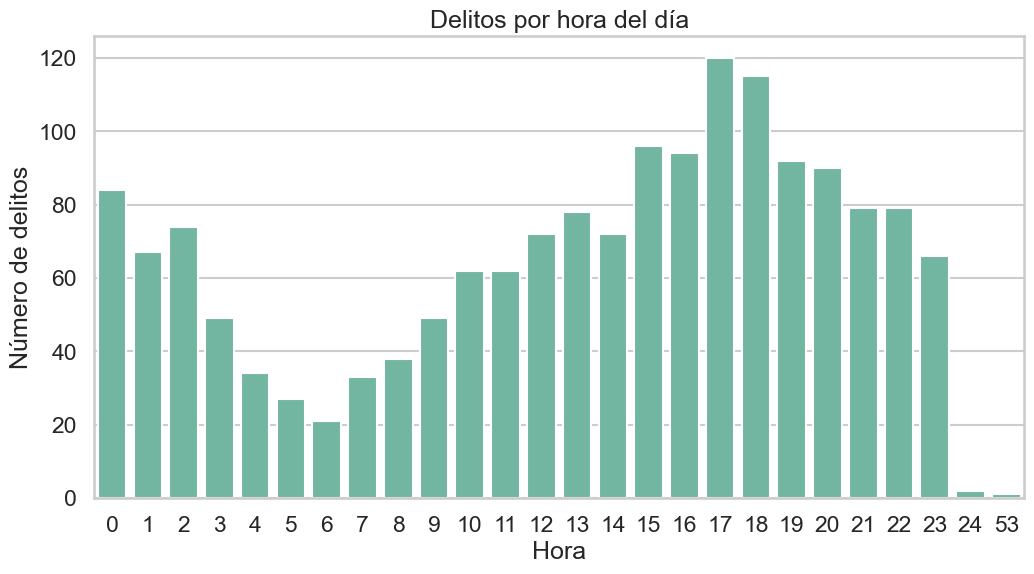

In [74]:

df = pd.read_csv("Bias_Crime.csv")

# Ver primeras filas

print(df[["TIME_OF_OFFENSE"]].head(20))


# Extraer hora inicial

# Si hay rangos tipo:
# 1808-1809
# nos quedamos con 1808

df["START_TIME"] = (
    df["TIME_OF_OFFENSE"]
    .astype(str)
    .str.split('-')
    .str[0]
)

# Completar con ceros

# Convierte:
# 915 -> 0915

df["START_TIME"] = df["START_TIME"].str.zfill(4)

# Extraer la hora

# 1808 -> 18
# 0210 -> 02

df["HOUR"] = df["START_TIME"].str[:2]

# 6. Convertir a número

df["HOUR"] = pd.to_numeric(
    df["HOUR"],
    errors="coerce"
)

# Verificar resultado

print(df[["TIME_OF_OFFENSE", "START_TIME", "HOUR"]].head(20))

# Crear gráfico

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="HOUR",
    order=sorted(df["HOUR"].dropna().unique())
)

plt.title("Delitos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de delitos")

plt.show()

## Grupos más afectados

In [75]:
df["GROUP_CATEGORY"] = df["TARGETED_GROUP"].apply(agrupar_grupo)

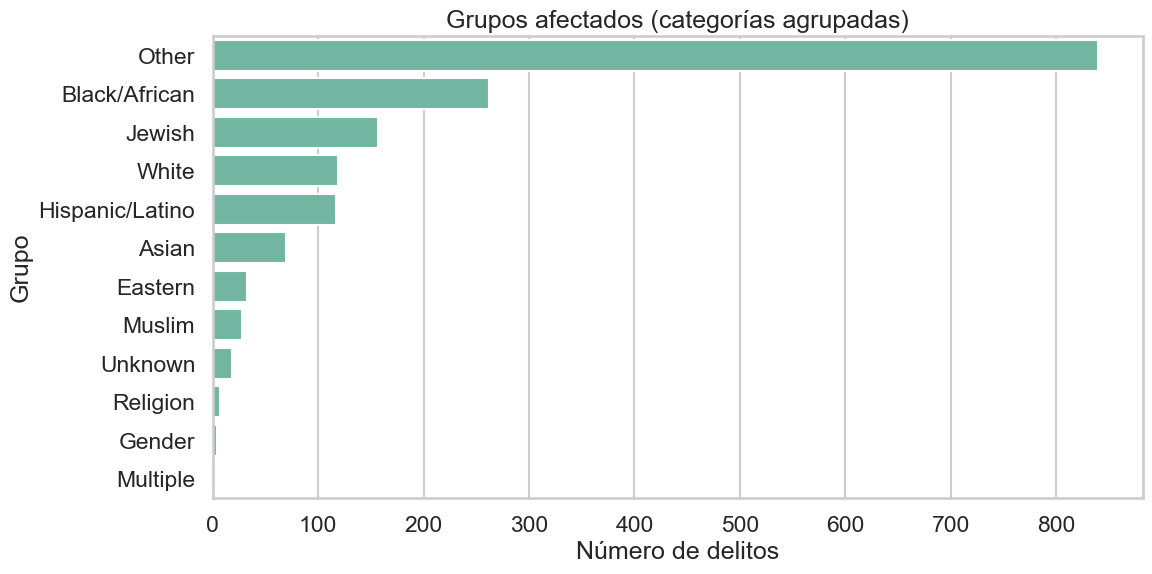

In [76]:
# Uso GROUP_CATEGORY que he creado en la limpieza de datos

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="GROUP_CATEGORY",
    order=df["GROUP_CATEGORY"].value_counts().index
)

plt.title("Grupos afectados (categorías agrupadas)")
plt.xlabel("Número de delitos")
plt.ylabel("Grupo")

plt.show()

In [109]:
print(df["GROUP_CATEGORY"].value_counts())

GROUP_CATEGORY
Other              829
Black/African      260
Jewish             157
White              118
Hispanic/Latino    117
Asian               69
Eastern             33
Muslim              27
Unknown             18
Religion             7
Gender               4
Multiple             1
Name: count, dtype: int64


## Busco otra opción a este gráfico

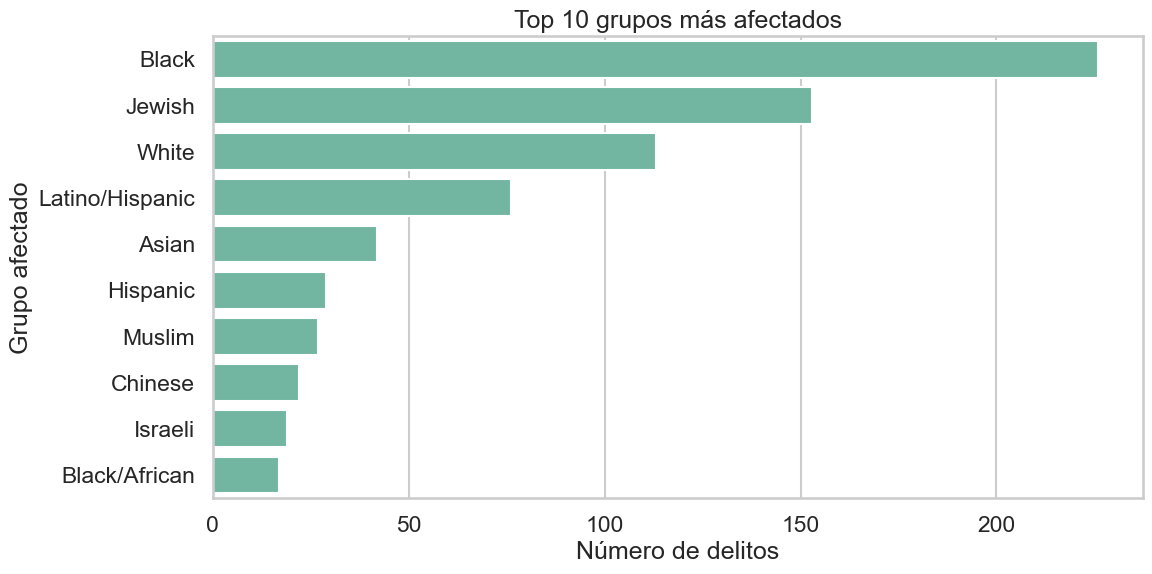

In [77]:
# Uso la columna original TARGETED_GROUP, limitando a 10 grupos

plt.figure(figsize=(12,6))

top_groups = df["TARGETED_GROUP"].value_counts().nlargest(10)

sns.barplot(
    x=top_groups.values,
    y=top_groups.index
)

plt.title("Top 10 grupos más afectados")
plt.xlabel("Número de delitos")
plt.ylabel("Grupo afectado")

plt.show()

In [110]:
print(df["TARGETED_GROUP"].value_counts())

TARGETED_GROUP
Black                            226
Jewish                           153
White                            112
Latino/Hispanic                   76
Asian                             42
Hispanic                          29
Muslim                            26
Chinese                           21
Israeli                           19
Black/African                     17
Arab/Middle Eastern               17
Unspecified                       15
African                           11
Middle Eastern                     9
Mexican                            9
Ethiopian                          5
Female                             4
Palestinian                        4
Catholic                           4
Non-European                       3
Russian                            2
Indian                             2
Christian                          2
ADW                                2
Unknown                            2
Jamaican                           1
Hindu                  

## Tipos de delito

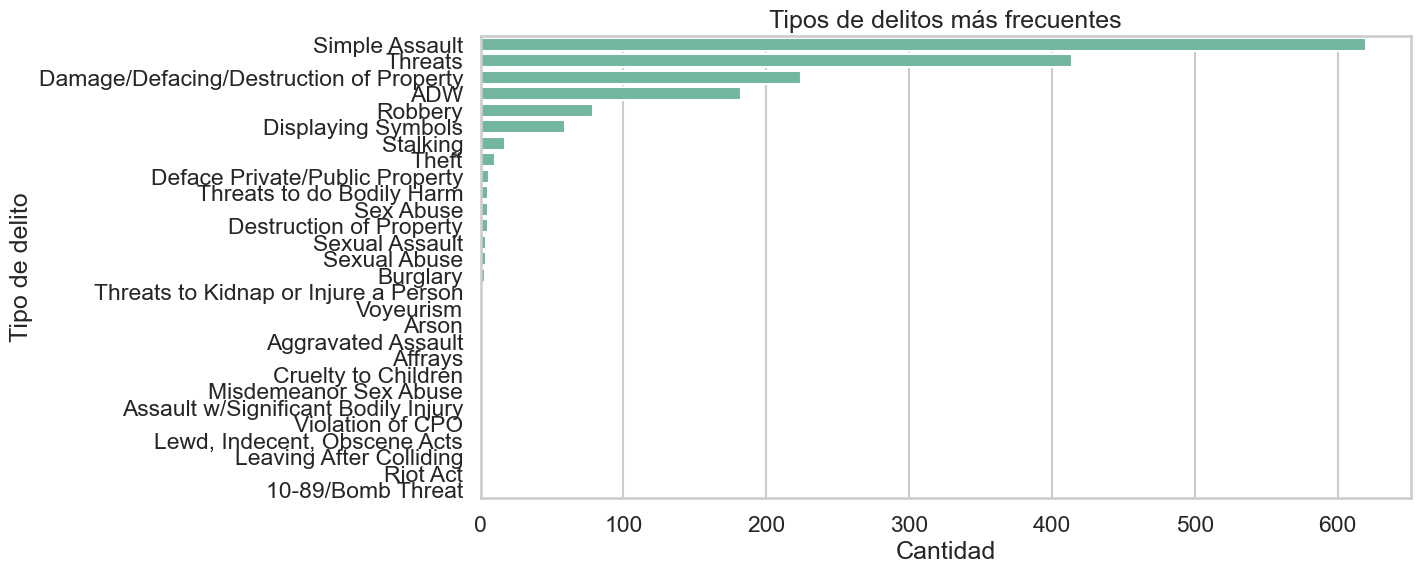

In [78]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="TOP_OFFENSE_TYPE",
    order=df["TOP_OFFENSE_TYPE"].value_counts().index
)

plt.title("Tipos de delitos más frecuentes")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de delito")

plt.show()

In [111]:
print(df["TOP_OFFENSE_TYPE"].value_counts())

TOP_OFFENSE_TYPE
Simple Assault                             614
Threats                                    412
Damage/Defacing/Destruction of Property    223
ADW                                        178
Robbery                                     76
Displaying Symbols                          59
Stalking                                    17
Theft                                       10
Deface Private/Public Property               6
Threats to do Bodily Harm                    5
Sex Abuse                                    5
Destruction of Property                      5
Sexual Assault                               4
Sexual Abuse                                 4
Burglary                                     3
Threats to Kidnap or Injure a Person         2
Voyeurism                                    1
Arson                                        1
Aggravated Assault                           1
Affrays                                      1
Cruelty to Children                        

## Top 10 tipos de delitos más frecuentes

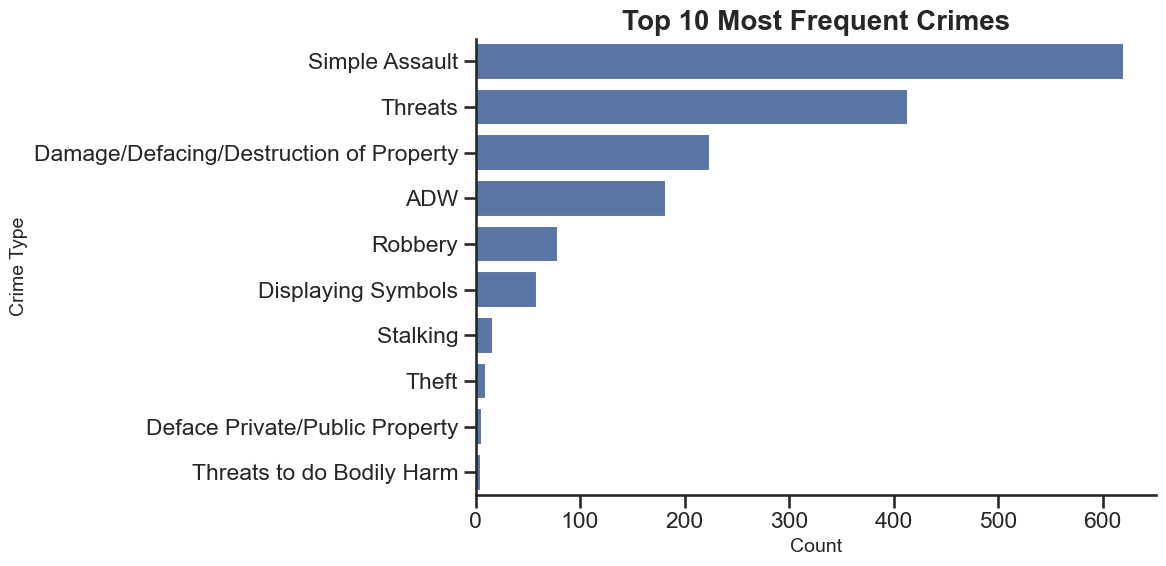

In [79]:

# ESTILO
sns.set_theme(style="ticks", context="talk")

# OBTENER LOS 10 DELITOS MÁS FRECUENTES
top_10 = (
    df["TOP_OFFENSE_TYPE"]
    .value_counts()
    .head(10)
)

# CREAR GRÁFICO
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10.values,
    y=top_10.index
)

# TÍTULOS
plt.title(
    "Top 10 Most Frequent Crimes",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Count", fontsize=14)
plt.ylabel("Crime Type", fontsize=14)

# QUITAR GRID
plt.grid(False)

# QUITAR BORDES SUPERIOR Y DERECHO
sns.despine()

plt.tight_layout()

plt.show()

In [112]:
print(df["TOP_OFFENSE_TYPE"].value_counts())

TOP_OFFENSE_TYPE
Simple Assault                             614
Threats                                    412
Damage/Defacing/Destruction of Property    223
ADW                                        178
Robbery                                     76
Displaying Symbols                          59
Stalking                                    17
Theft                                       10
Deface Private/Public Property               6
Threats to do Bodily Harm                    5
Sex Abuse                                    5
Destruction of Property                      5
Sexual Assault                               4
Sexual Abuse                                 4
Burglary                                     3
Threats to Kidnap or Injure a Person         2
Voyeurism                                    1
Arson                                        1
Aggravated Assault                           1
Affrays                                      1
Cruelty to Children                        

## Tipo de odio

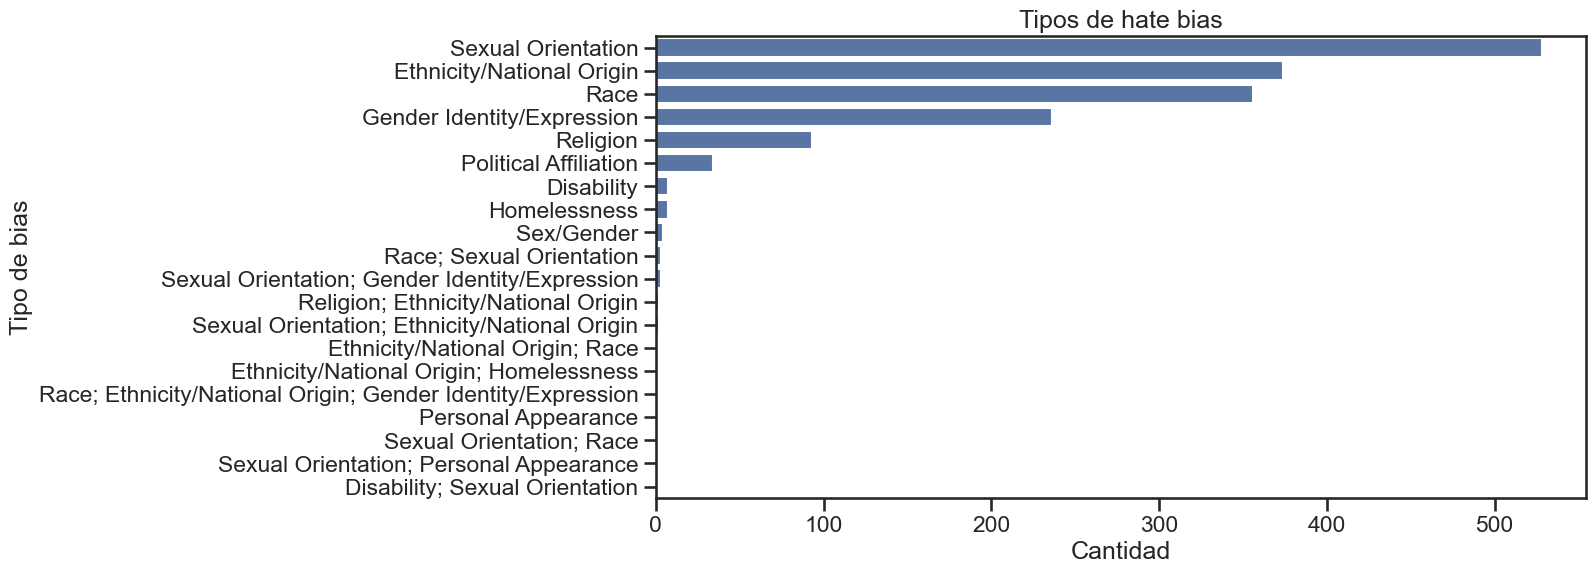

In [80]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="TYPE_OF_HATE_BIAS",
    order=df["TYPE_OF_HATE_BIAS"].value_counts().index
)

plt.title("Tipos de hate bias")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de bias")

plt.show()

In [113]:
print(df["TYPE_OF_HATE_BIAS"].value_counts())

TYPE_OF_HATE_BIAS
Sexual Orientation                                             523
Ethnicity/National Origin                                      371
Race                                                           355
Gender Identity/Expression                                     230
Religion                                                        92
Political Affiliation                                           34
Disability                                                       7
Homelessness                                                     7
Sex/Gender                                                       4
Race; Sexual Orientation                                         3
Sexual Orientation; Gender Identity/Expression                   3
Religion; Ethnicity/National Origin                              2
Sexual Orientation; Ethnicity/National Origin                    2
Ethnicity/National Origin; Race                                  1
Ethnicity/National Origin; Homelessness     

## Porcentaje del tipo de delito respecto del total

/var/folders/j0/8nk7kb3139sfbx5j_s7f539m0000gn/T/ipykernel_4008/2304376504.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


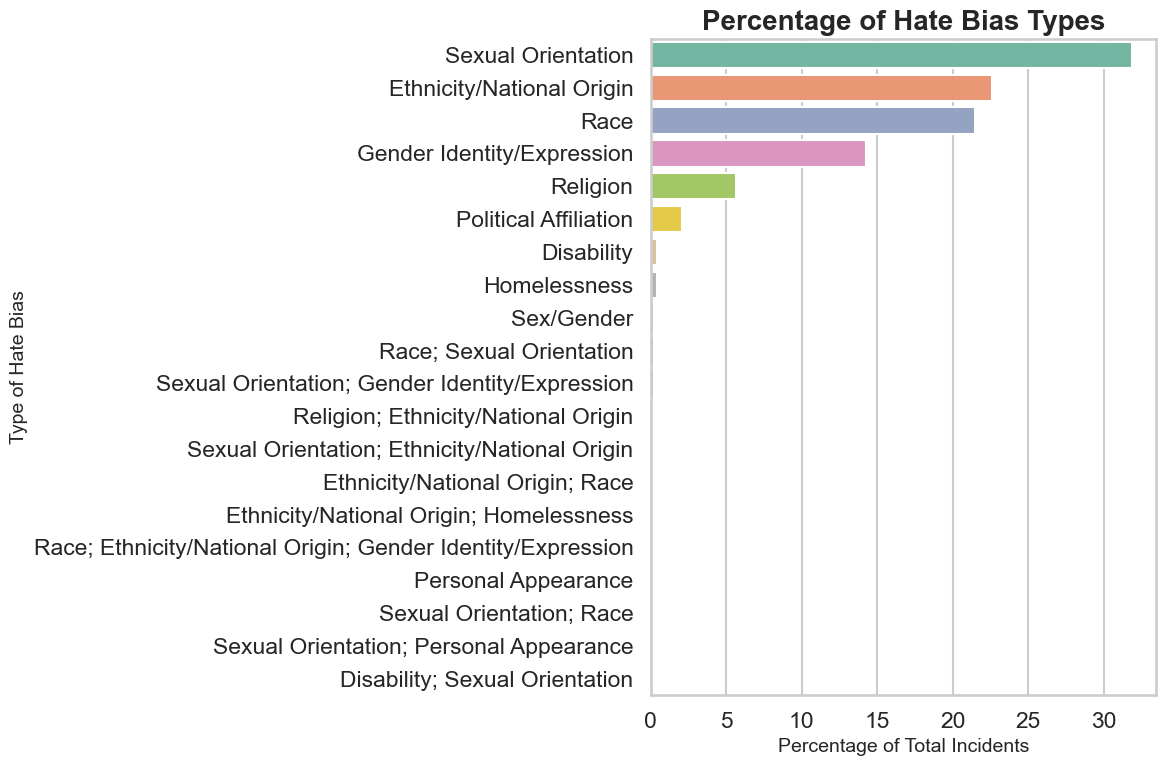

In [81]:

# CONTAR TIPOS DE HATE BIAS

bias_counts = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .reset_index()
)

# RENOMBRAR COLUMNAS

bias_counts.columns = [
    "TYPE_OF_HATE_BIAS",
    "COUNT"
]

# CALCULAR PORCENTAJES

total = bias_counts["COUNT"].sum()

bias_counts["PERCENTAGE"] = (
    bias_counts["COUNT"] / total * 100
)

# REDONDEAR

bias_counts["PERCENTAGE"] = (
    bias_counts["PERCENTAGE"]
    .round(2)
)

# ESTILO

sns.set_style("whitegrid")

# GRÁFICO

plt.figure(figsize=(12,8))

sns.barplot(
    data=bias_counts,
    x="PERCENTAGE",
    y="TYPE_OF_HATE_BIAS",
    palette="Set2"
)

# PERSONALIZACIÓN

plt.title(
    "Percentage of Hate Bias Types",
    fontsize=20,
    weight="bold"
)

plt.xlabel(
    "Percentage of Total Incidents",
    fontsize=14
)

plt.ylabel(
    "Type of Hate Bias",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [114]:
print(bias_counts["PERCENTAGE"].round(2))

0     31.88
1     22.58
2     21.50
3     14.25
4      5.62
5      2.05
6      0.42
7      0.42
8      0.24
9      0.18
10     0.18
11     0.12
12     0.12
13     0.06
14     0.06
15     0.06
16     0.06
17     0.06
18     0.06
19     0.06
Name: PERCENTAGE, dtype: float64


## Cómo varían los porcentajes según la presidencia

/var/folders/j0/8nk7kb3139sfbx5j_s7f539m0000gn/T/ipykernel_4008/341286303.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("PRESIDENT")["COUNT"]


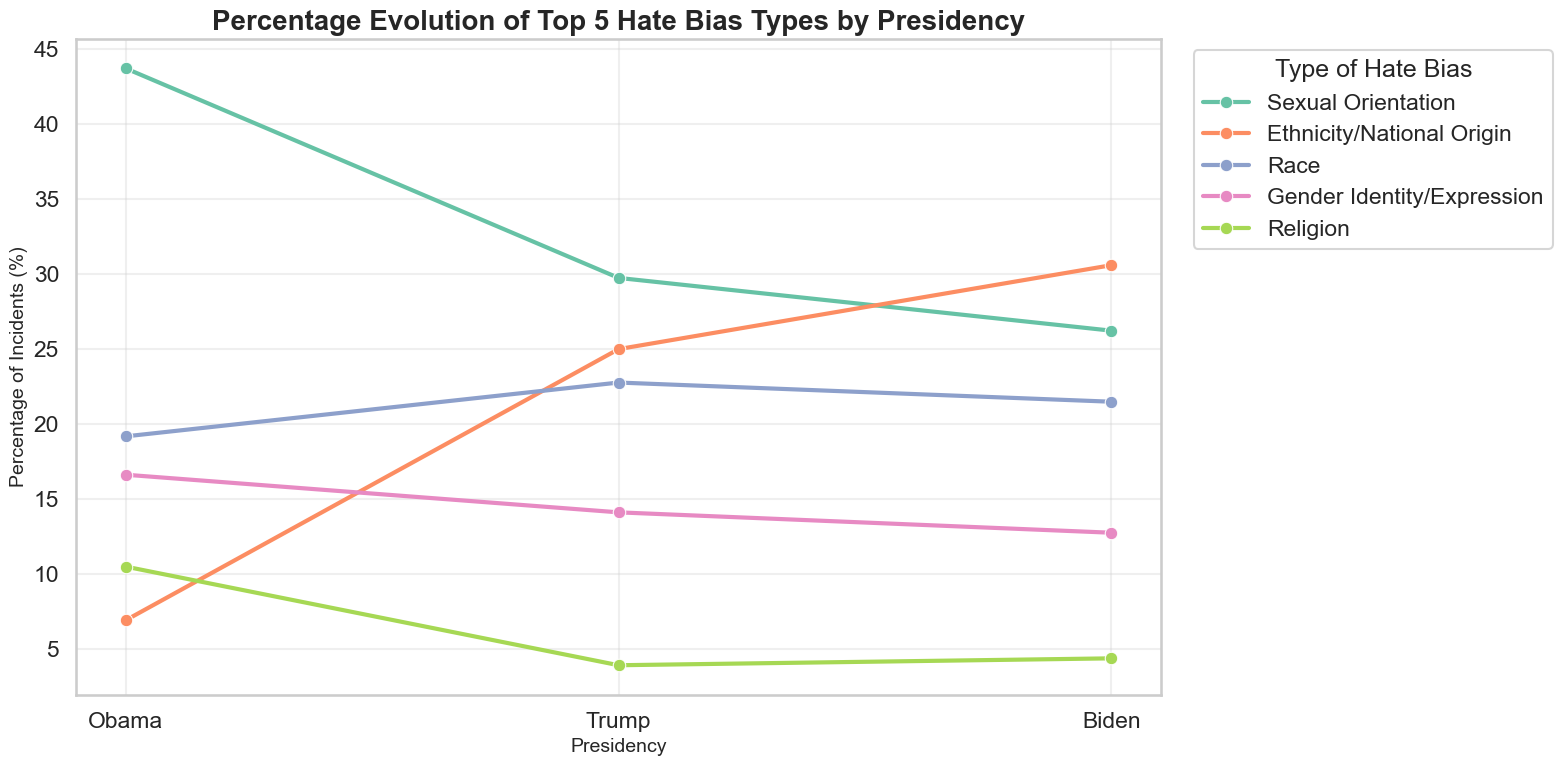

In [82]:
# CONVERTIR FECHA

df["DATE_OF_OFFENSE"] = pd.to_datetime(
    df["DATE_OF_OFFENSE"]
)

# CREAR COLUMNA YEAR

df["YEAR"] = (
    df["DATE_OF_OFFENSE"]
    .dt.year
)

# ASIGNAR PRESIDENCIA

def assign_president(year):

    if 2012 <= year <= 2016:
        return "Obama"

    elif 2017 <= year <= 2020:
        return "Trump"

    elif 2021 <= year <= 2024:
        return "Biden"

df["PRESIDENT"] = (
    df["YEAR"]
    .apply(assign_president)
)

# DEFINIR ORDEN TEMPORAL CORRECTO

president_order = [
    "Obama",
    "Trump",
    "Biden"
]

df["PRESIDENT"] = pd.Categorical(
    df["PRESIDENT"],
    categories=president_order,
    ordered=True
)

# CONTAR DELITOS

counts = (
    df
    .groupby(
        ["PRESIDENT", "TYPE_OF_HATE_BIAS"],
        observed=False
    )
    .size()
    .reset_index(name="COUNT")
)

# CALCULAR TOTALES

totals = (
    counts
    .groupby("PRESIDENT")["COUNT"]
    .transform("sum")
)

# CALCULAR PORCENTAJES

counts["PERCENTAGE"] = (
    counts["COUNT"] / totals * 100
)

# REDONDEAR

counts["PERCENTAGE"] = (
    counts["PERCENTAGE"]
    .round(2)
)

# TOP 5 HATE BIAS

top5 = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .head(5)
    .index
)

# FILTRAR TOP 5

counts_top5 = counts[
    counts["TYPE_OF_HATE_BIAS"]
    .isin(top5)
]

# ESTILO

sns.set_style("whitegrid")

# GRÁFICO

plt.figure(figsize=(16,8))

sns.lineplot(
    data=counts_top5,
    x="PRESIDENT",
    y="PERCENTAGE",
    hue="TYPE_OF_HATE_BIAS",
    hue_order=top5,
    marker="o",
    linewidth=3,
    palette="Set2"
)

# PERSONALIZACIÓN

plt.title(
    "Percentage Evolution of Top 5 Hate Bias Types by Presidency",
    fontsize=20,
    weight="bold"
)

plt.xlabel(
    "Presidency",
    fontsize=14
)

plt.ylabel(
    "Percentage of Incidents (%)",
    fontsize=14
)

plt.legend(
    title="Type of Hate Bias",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Cómo evolucionan los top 5 hate bias

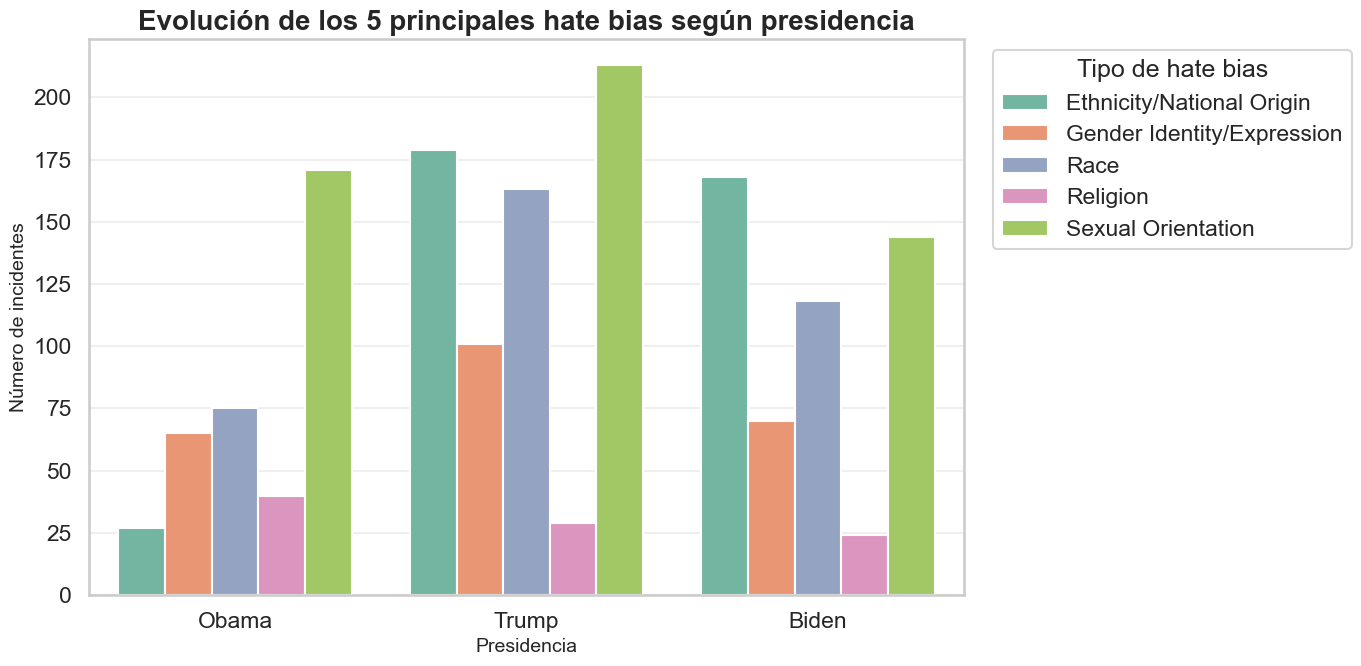

In [83]:

# ESTILO

sns.set_style("whitegrid")

# TOP 5 HATE BIAS

top5 = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .head(5)
    .index
)

# FILTRAR TOP 5

df_top = df[
    df["TYPE_OF_HATE_BIAS"].isin(top5)
].copy()

# ASIGNAR PRESIDENTE

def president(year):

    if 2012 <= year <= 2016:
        return "Obama"

    elif 2017 <= year <= 2020:
        return "Trump"

    elif 2021 <= year <= 2024:
        return "Biden"

df_top["PRESIDENT"] = df_top["REPORT_YEAR"].apply(president)

# CONTAR INCIDENTES

counts = (
    df_top.groupby(
        ["PRESIDENT", "TYPE_OF_HATE_BIAS"]
    )
    .size()
    .reset_index(name="COUNT")
)

# ORDEN PRESIDENTES

president_order = [
    "Obama",
    "Trump",
    "Biden"
]

counts["PRESIDENT"] = pd.Categorical(
    counts["PRESIDENT"],
    categories=president_order,
    ordered=True
)

# ORDENAR DATAFRAME

counts = counts.sort_values("PRESIDENT")

# GRÁFICO

plt.figure(figsize=(14,7))

sns.barplot(
    data=counts,
    x="PRESIDENT",
    y="COUNT",
    hue="TYPE_OF_HATE_BIAS",
    order=president_order,
    palette="Set2"
)

# PERSONALIZACIÓN

plt.title(
    "Evolución de los 5 principales hate bias según presidencia",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Presidencia", fontsize=14)
plt.ylabel("Número de incidentes", fontsize=14)

plt.legend(
    title="Tipo de hate bias",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [115]:
print(counts)

   PRESIDENT           TYPE_OF_HATE_BIAS  COUNT
5      Obama   Ethnicity/National Origin     27
6      Obama  Gender Identity/Expression     65
7      Obama                        Race     75
8      Obama                    Religion     40
9      Obama          Sexual Orientation    171
10     Trump   Ethnicity/National Origin    179
11     Trump  Gender Identity/Expression    101
12     Trump                        Race    163
13     Trump                    Religion     29
14     Trump          Sexual Orientation    213
0      Biden   Ethnicity/National Origin    168
1      Biden  Gender Identity/Expression     70
2      Biden                        Race    118
3      Biden                    Religion     24
4      Biden          Sexual Orientation    144


In [126]:
print(counts.groupby("PRESIDENT")["COUNT"].sum())

PRESIDENT
Obama    378
Trump    685
Biden    524
Name: COUNT, dtype: int64


/var/folders/j0/8nk7kb3139sfbx5j_s7f539m0000gn/T/ipykernel_4008/2195922202.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(counts.groupby("PRESIDENT")["COUNT"].sum())


## Frecuencia de tipo de delito por periodo presidencial

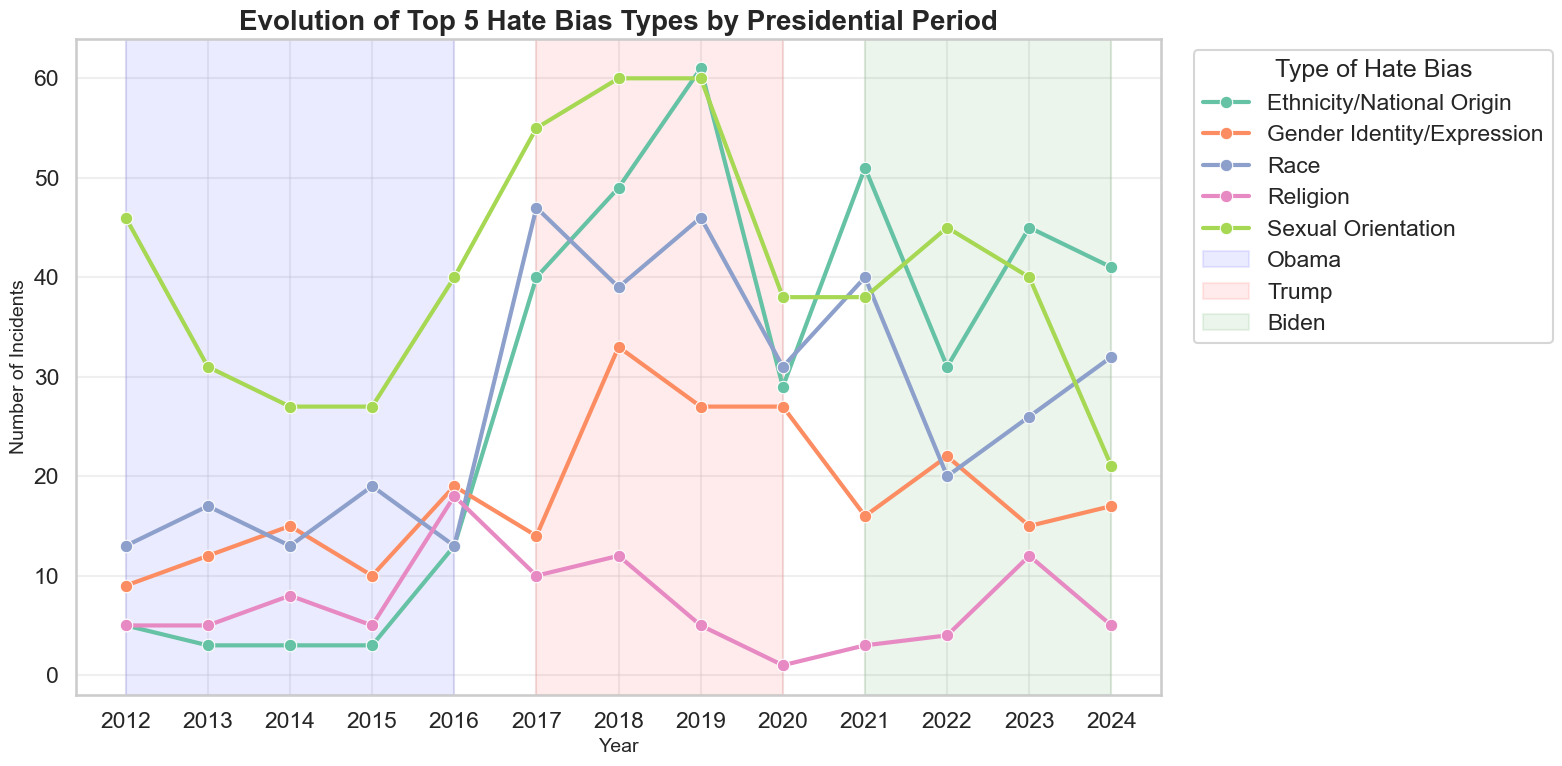

In [84]:
# ESTILO

sns.set_style("whitegrid")

# CREAR COLUMNA YEAR

df["YEAR"] = (
    df["DATE_OF_OFFENSE"]
    .dt.year
)

# TOP 5 TIPOS DE HATE BIAS

top5 = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .head(5)
    .index
)

# FILTRAR TOP 5

df_top = df[
    df["TYPE_OF_HATE_BIAS"].isin(top5)
].copy()

# CONTAR INCIDENTES POR AÑO

yearly_counts = (
    df_top
    .groupby(
        ["YEAR", "TYPE_OF_HATE_BIAS"]
    )
    .size()
    .reset_index(name="COUNT")
)

# GRÁFICO

plt.figure(figsize=(16,8))

sns.lineplot(
    data=yearly_counts,
    x="YEAR",
    y="COUNT",
    hue="TYPE_OF_HATE_BIAS",
    marker="o",
    linewidth=3,
    palette="Set2"
)

# PERIODOS PRESIDENCIALES

plt.axvspan(
    2012,
    2016,
    alpha=0.08,
    color="blue",
    label="Obama"
)

plt.axvspan(
    2017,
    2020,
    alpha=0.08,
    color="red",
    label="Trump"
)

plt.axvspan(
    2021,
    2024,
    alpha=0.08,
    color="green",
    label="Biden"
)

# PERSONALIZACIÓN

plt.title(
    "Evolution of Top 5 Hate Bias Types by Presidential Period",
    fontsize=20,
    weight="bold"
)

plt.xlabel(
    "Year",
    fontsize=14
)

plt.ylabel(
    "Number of Incidents",
    fontsize=14
)

plt.xticks(
    sorted(df_top["YEAR"].unique())
)

plt.legend(
    title="Type of Hate Bias",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [116]:
print(yearly_counts)

    YEAR           TYPE_OF_HATE_BIAS  COUNT
0   2012   Ethnicity/National Origin      5
1   2012  Gender Identity/Expression      9
2   2012                        Race     13
3   2012                    Religion      5
4   2012          Sexual Orientation     46
..   ...                         ...    ...
60  2024   Ethnicity/National Origin     41
61  2024  Gender Identity/Expression     17
62  2024                        Race     32
63  2024                    Religion      5
64  2024          Sexual Orientation     21

[65 rows x 3 columns]


## Distritos con más delitos

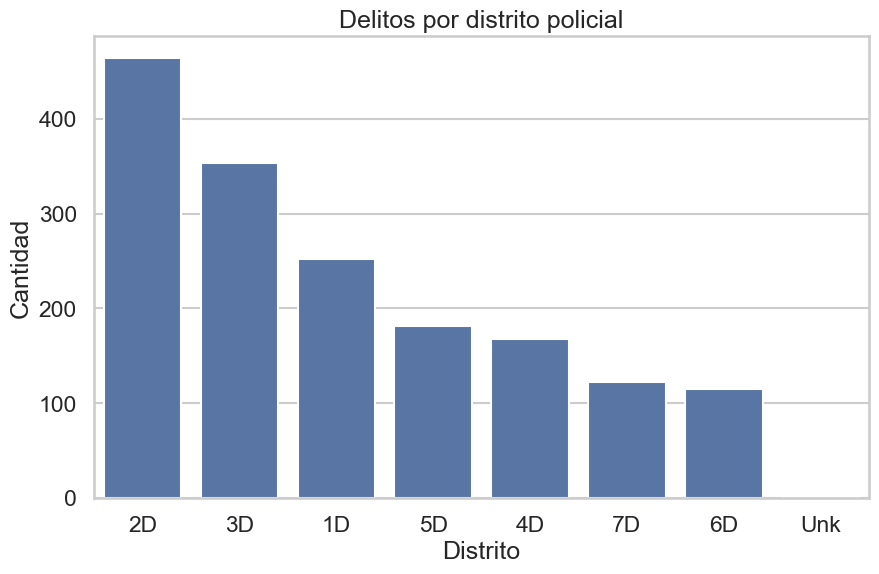

In [85]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="POLICE_DISTRICT",
    order=df["POLICE_DISTRICT"].value_counts().index
)

plt.title("Delitos por distrito policial")
plt.xlabel("Distrito")
plt.ylabel("Cantidad")

plt.show()

In [117]:
print(df["POLICE_DISTRICT"].value_counts())

POLICE_DISTRICT
2D     462
3D     352
1D     250
5D     180
4D     165
7D     120
6D     110
Unk      1
Name: count, dtype: int64


In [86]:
# CONTAR INCIDENTES POR DISTRITO POLICIAL

district_counts = (
    df["POLICE_DISTRICT"]
    .value_counts()
    .reset_index()
)

# RENOMBRAR COLUMNAS

district_counts.columns = [
    "POLICE_DISTRICT",
    "COUNT"
]

# TOTAL INCIDENTES

total_cases = district_counts["COUNT"].sum()

# CALCULAR PORCENTAJES

district_counts["PERCENTAGE"] = (
    district_counts["COUNT"]
    / total_cases
    * 100
)

# REDONDEAR

district_counts["PERCENTAGE"] = (
    district_counts["PERCENTAGE"]
    .round(2)
)

# ORDENAR

district_counts = district_counts.sort_values(
    by="PERCENTAGE",
    ascending=False
)

# MOSTRAR RESULTADOS

print(district_counts)

  POLICE_DISTRICT  COUNT  PERCENTAGE
0              2D    464       28.02
1              3D    353       21.32
2              1D    252       15.22
3              5D    181       10.93
4              4D    168       10.14
5              7D    122        7.37
6              6D    115        6.94
7             Unk      1        0.06


## Delitos por distrito (ward)

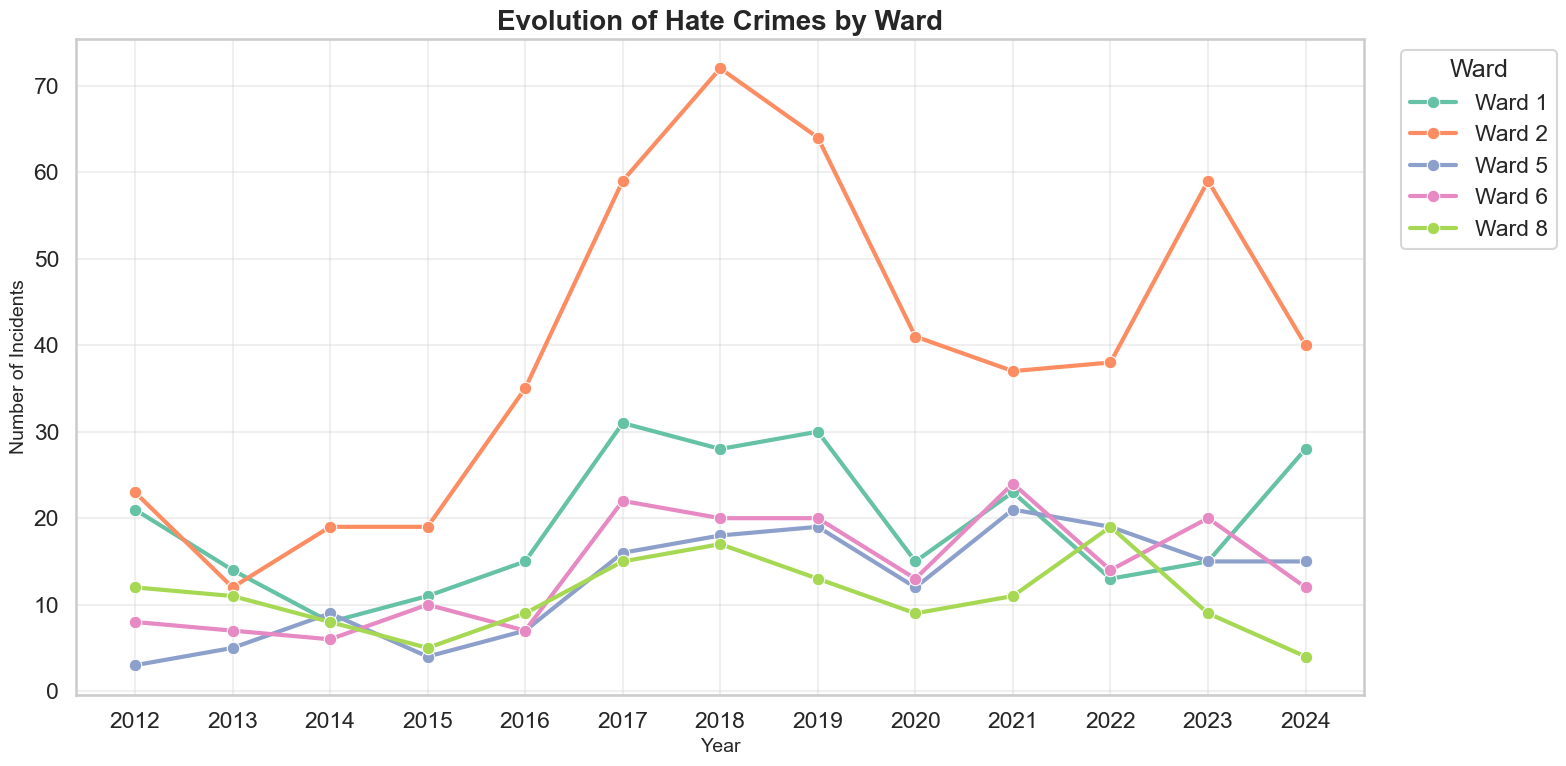

In [87]:


# ESTILO

sns.set_style("whitegrid")

# CREAR COLUMNA YEAR

df["YEAR"] = (
    df["DATE_OF_OFFENSE"]
    .dt.year
)

# TOP 5 WARDS CON MÁS INCIDENTES

top_wards = (
    df["WARD"]
    .value_counts()
    .head(5)
    .index
)

# FILTRAR TOP WARDS

df_wards = df[
    df["WARD"].isin(top_wards)
].copy()

# CONTAR INCIDENTES POR AÑO Y WARD

ward_evolution = (
    df_wards
    .groupby(
        ["YEAR", "WARD"]
    )
    .size()
    .reset_index(name="COUNT")
)

# GRÁFICO

plt.figure(figsize=(16,8))

sns.lineplot(
    data=ward_evolution,
    x="YEAR",
    y="COUNT",
    hue="WARD",
    marker="o",
    linewidth=3,
    palette="Set2"
)

# PERSONALIZACIÓN

plt.title(
    "Evolution of Hate Crimes by Ward",
    fontsize=20,
    weight="bold"
)

plt.xlabel(
    "Year",
    fontsize=14
)

plt.ylabel(
    "Number of Incidents",
    fontsize=14
)

plt.xticks(
    sorted(df_wards["YEAR"].unique())
)

plt.legend(
    title="Ward",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [118]:
print(ward_evolution)

    YEAR    WARD  COUNT
0   2012  Ward 1     21
1   2012  Ward 2     23
2   2012  Ward 5      3
3   2012  Ward 6      8
4   2012  Ward 8     12
..   ...     ...    ...
60  2024  Ward 1     28
61  2024  Ward 2     40
62  2024  Ward 5     15
63  2024  Ward 6     12
64  2024  Ward 8      4

[65 rows x 3 columns]


## Porcentaje de incidencia de casos por ward

In [88]:
# ELIMINAR WARDS COMBINADOS

df_wards = df[
    ~df["WARD"].astype(str).str.contains(
        ",|/",
        na=False
    )
].copy()

# CONTAR INCIDENTES POR WARD

ward_counts = (
    df_wards["WARD"]
    .value_counts()
    .reset_index()
)

# RENOMBRAR COLUMNAS

ward_counts.columns = [
    "WARD",
    "COUNT"
]

# TOTAL INCIDENTES

total_cases = ward_counts["COUNT"].sum()

# CALCULAR PORCENTAJES

ward_counts["PERCENTAGE"] = (
    ward_counts["COUNT"] / total_cases * 100
)

# REDONDEAR

ward_counts["PERCENTAGE"] = (
    ward_counts["PERCENTAGE"]
    .round(2)
)

# ORDENAR

ward_counts = ward_counts.sort_values(
    by="PERCENTAGE",
    ascending=False
)

# MOSTRAR RESULTADOS

print(ward_counts)

     WARD  COUNT  PERCENTAGE
0  Ward 2    518       32.29
1  Ward 1    252       15.71
2  Ward 6    183       11.41
3  Ward 5    163       10.16
4  Ward 8    142        8.85
5  Ward 4    127        7.92
6  Ward 7    117        7.29
7  Ward 3    101        6.30
8  ward 1      1        0.06


## Heatmap de los top 5 delitos de odio por periodo presidencia

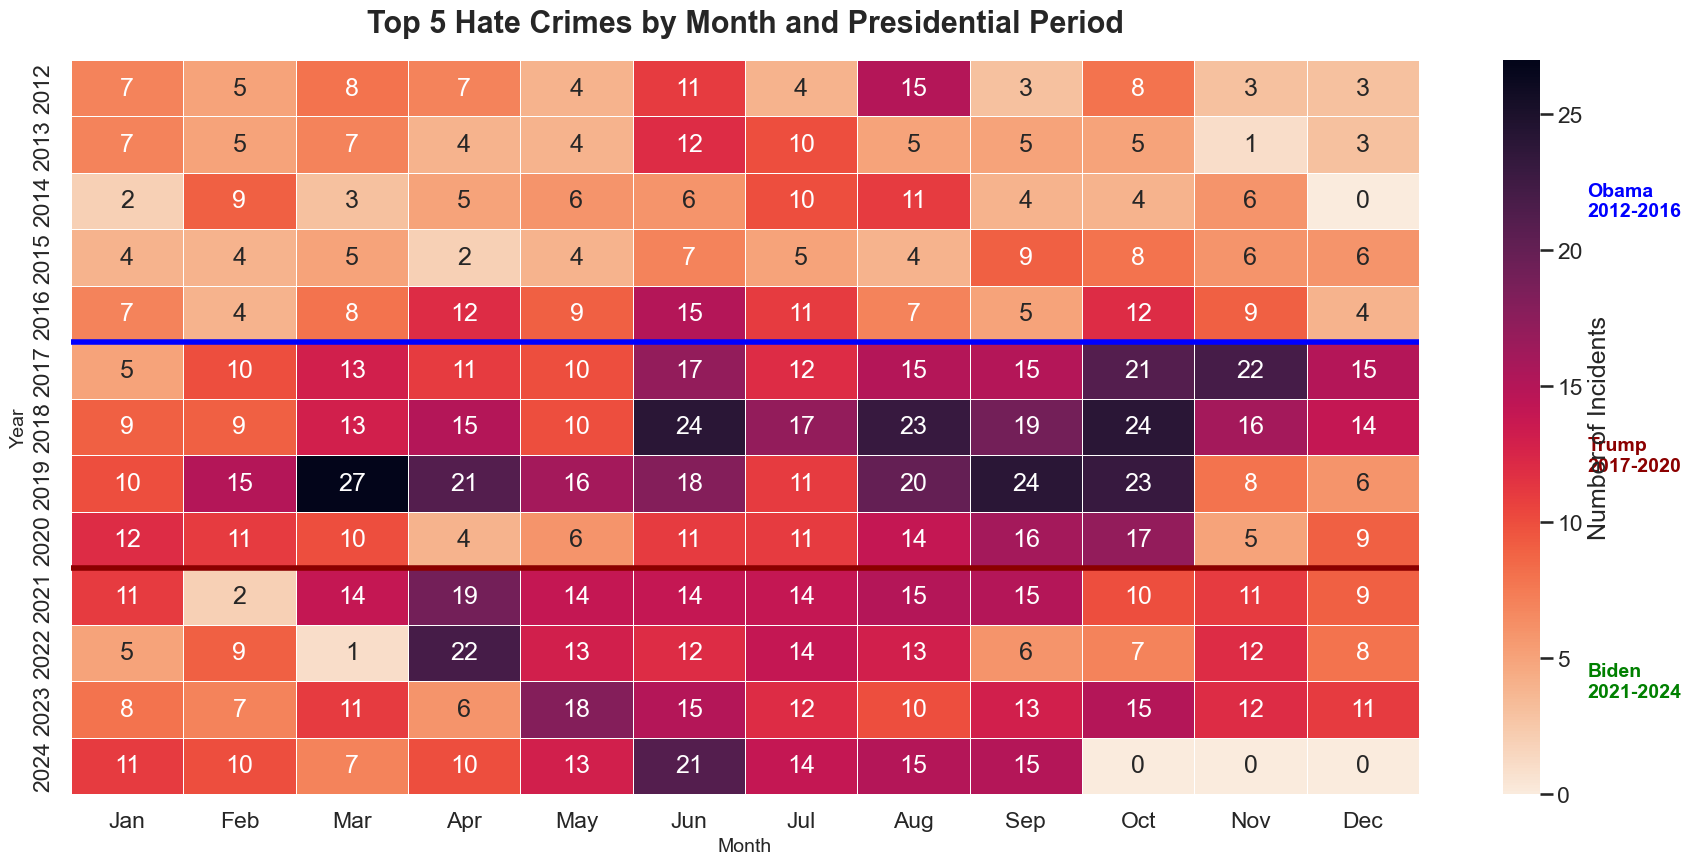

In [89]:
# ESTILO

sns.set_style("white")

# CREAR VARIABLES TEMPORALES

df["YEAR"] = (
    df["DATE_OF_OFFENSE"]
    .dt.year
)

df["MONTH"] = (
    df["DATE_OF_OFFENSE"]
    .dt.month
)

# TOP 5 HATE BIAS

top5 = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .head(5)
    .index
)

# FILTRAR TOP 5

df_top = df[
    df["TYPE_OF_HATE_BIAS"]
    .isin(top5)
].copy()

# CONTAR INCIDENTES POR AÑO Y MES

heatmap_data = (
    df_top
    .groupby(
        ["YEAR", "MONTH"]
    )
    .size()
    .reset_index(name="COUNT")
)

# CREAR MATRIZ

heatmap_matrix = (
    heatmap_data
    .pivot(
        index="YEAR",
        columns="MONTH",
        values="COUNT"
    )
    .fillna(0)
)

# RENOMBRAR MESES

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

heatmap_matrix.columns = month_labels

# GRÁFICO

plt.figure(figsize=(18,9))

ax = sns.heatmap(
    heatmap_matrix,
    cmap="rocket_r",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={
        "label": "Number of Incidents"
    }
)

# TÍTULO

plt.title(
    "Top 5 Hate Crimes by Month and Presidential Period",
    fontsize=22,
    weight="bold",
    pad=20
)

# ETIQUETAS EJES

plt.xlabel(
    "Month",
    fontsize=14
)

plt.ylabel(
    "Year",
    fontsize=14
)

# SEPARADORES PRESIDENCIALES

plt.axhline(
    y=5,
    color="blue",
    linewidth=4
)

plt.axhline(
    y=9,
    color="darkred",
    linewidth=4
)

# NOMBRES PRESIDENTES

plt.text(
    13.5,
    2.5,
    "Obama\n2012-2016",
    fontsize=14,
    weight="bold",
    color="blue",
    va="center"
)

plt.text(
    13.5,
    7,
    "Trump\n2017-2020",
    fontsize=14,
    weight="bold",
    color="darkred",
    va="center"
)

plt.text(
    13.5,
    11,
    "Biden\n2021-2024",
    fontsize=14,
    weight="bold",
    color="green",
    va="center"
)

# AJUSTE FINAL

plt.tight_layout()

plt.show()

## Heatmap de correlaciones

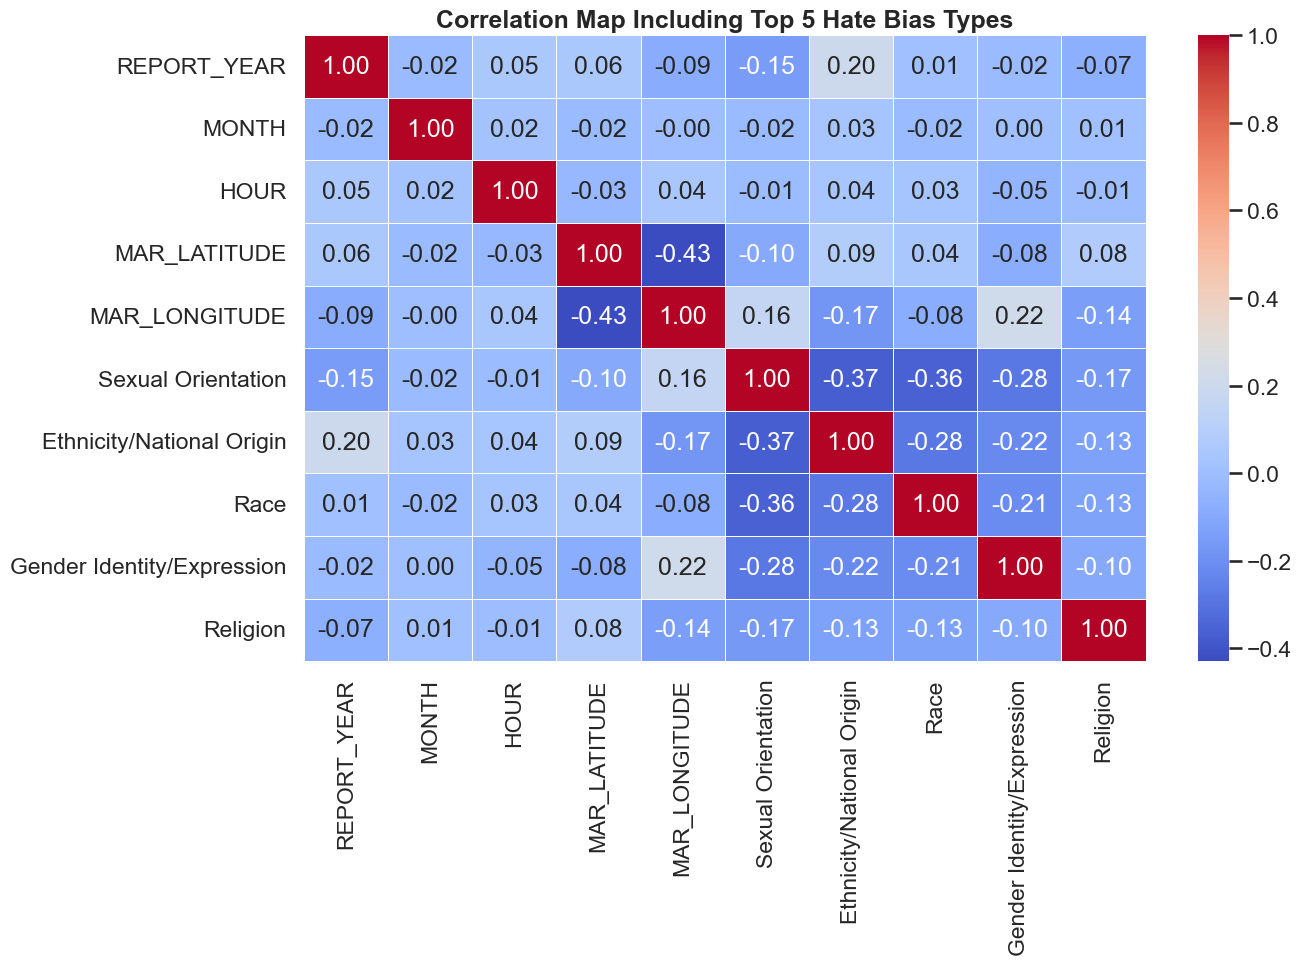

In [90]:

# TOP 5 TIPOS DE HATE BIAS

top5 = (
    df["TYPE_OF_HATE_BIAS"]
    .value_counts()
    .head(5)
    .index
)

# CREAR COLUMNAS BINARIAS

for bias in top5:

    df[bias] = (
        df["TYPE_OF_HATE_BIAS"] == bias
    ).astype(int)

# SELECCIONAR VARIABLES

corr_df = df[[
    "REPORT_YEAR",
    "MONTH",
    "HOUR",
    "MAR_LATITUDE",
    "MAR_LONGITUDE",
    *top5
]]

# MATRIZ DE CORRELACIÓN

corr_matrix = corr_df.corr()

# HEATMAP

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# TÍTULO

plt.title(
    "Correlation Map Including Top 5 Hate Bias Types",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ANÁLISIS GEOGRÁFICO

In [91]:
import pandas as pd
import folium

# Convertir coordenadas a números
df["MAR_LATITUDE"] = pd.to_numeric(df["MAR_LATITUDE"], errors="coerce")
df["MAR_LONGITUDE"] = pd.to_numeric(df["MAR_LONGITUDE"], errors="coerce")

# Eliminar filas con coordenadas vacías
df = df.dropna(subset=["MAR_LATITUDE", "MAR_LONGITUDE"])

# Crear mapa centrado
mapa = folium.Map(
    location=[38.9072, -77.0369],
    zoom_start=11
)

# Añadir puntos
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["MAR_LATITUDE"], row["MAR_LONGITUDE"]],
        radius=2,
        fill=True
    ).add_to(mapa)

# Guardar mapa
mapa.save("bias_crime_map.html")

print("Mapa generado correctamente")

Mapa generado correctamente
